In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df6 = pd.read_csv(r".\log\step2.csv")
df6 = df6.drop(['Unnamed: 0'], axis=1, errors='ignore')
df6

,frequency,355.26607692224155,227.52736891479316,228.1048056598934,508.4579820682637,624.7739429956808,509.2412520609261,746.6584998199332,738.8342325716347,744.5957020753282,...,854.7166023522125,858.2383815524672,851.444148653565,887.258212048309,912.2418726871764,911.7194528327119,1047.003667471031,1047.5534428923963,1000.9177192045671,Max_Oxygen_LifeTime
0,0.2,15.693691,9.443991,1.249940,0.000000,34.094721,0.000000,6.857589,167.325163,5.486071,...,18.577831,0.000000,0.000000,0.000000,386.246099,0.000000,15.371201,12.332707,5.183312,0.459737
1,0.2,0.000000,14.682523,0.000000,0.000000,103.661344,0.000000,31.635450,318.990789,0.000000,...,87.348993,0.000000,43.410868,0.000000,756.836451,1.259714,29.981204,34.012291,0.000000,0.971616
2,0.2,6.163256,29.393991,0.000000,46.937403,237.872811,100.458785,12.768803,501.175525,0.000000,...,58.736495,0.000000,120.452377,0.000000,1054.932155,15.863641,0.000000,12.812941,0.000000,0.911778
3,0.2,0.000000,13.837251,53.544146,0.000000,189.468595,114.004574,47.529882,645.434196,0.000000,...,120.985155,109.912853,163.654026,0.000000,1481.539146,25.550453,54.197931,33.293015,0.000000,0.939168
4,0.2,0.000000,22.551184,0.000000,8.134488,158.228915,106.273152,34.180944,740.674757,0.000000,...,67.573096,0.000000,180.896071,0.000000,1739.831124,12.438134,41.837360,36.183663,11.307395,0.841546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,1.0,11.021610,0.000000,0.000000,0.000000,15.287786,98.902616,107.145214,952.543208,191.080931,...,0.000000,0.000000,348.778338,68.356739,2267.961964,36.573251,23.226117,12.085988,2.627389,0.738645
575,1.0,16.868346,0.000000,0.000000,39.158921,0.000000,189.268120,92.778647,948.403947,120.379463,...,62.517511,112.731044,259.713704,122.042163,2514.359653,26.381320,0.000000,18.796691,15.718870,0.683652
576,1.0,21.019440,0.000000,0.000000,0.000000,0.000000,40.558919,0.000000,948.886917,49.319891,...,0.000000,0.000000,248.336071,81.273623,2804.664412,32.490893,38.805378,32.950128,15.154763,0.652843
577,1.0,32.316066,0.000000,0.000000,0.000000,0.000000,98.823214,144.473708,1428.856588,38.345568,...,0.000000,158.804880,436.519754,0.000000,3477.884529,56.334457,24.070177,22.405750,7.553939,0.622883


In [4]:
columns_list = df6.columns.to_list()
feature_list = columns_list.copy()
feature_list = feature_list[1:len(feature_list)-1]
feature_list
len(feature_list)

36

In [5]:
feature_list2 = [f"{float(x):.2f}" for x in feature_list]
feature_list2

['355.27',
 '227.53',
 '228.10',
 '508.46',
 '624.77',
 '509.24',
 '746.66',
 '738.83',
 '744.60',
 '749.06',
 '751.45',
 '751.79',
 '762.61',
 '772.37',
 '762.05',
 '793.35',
 '772.04',
 '772.70',
 '796.74',
 '800.00',
 '800.21',
 '801.05',
 '801.37',
 '805.12',
 '826.69',
 '826.19',
 '827.68',
 '854.72',
 '858.24',
 '851.44',
 '887.26',
 '912.24',
 '911.72',
 '1047.00',
 '1047.55',
 '1000.92']

In [6]:
# ==========================================
# 1. file path
# ==========================================

file1 = "nist_Ar.xlsx"   # Wavelength + Species
file2 = feature_list   #  Wavelength 
file3 = "other_wavelenght.xlsx"

In [7]:
df1 = pd.read_excel(file1)
df1 = df1.drop(['Intensity', 'Reference'], axis=1, errors='ignore')
df1['Air'] = df1['Air'].astype(float) / 10 
df3 = pd.read_excel(file3)
df3['Air'] = pd.to_numeric(df3['Air'], errors="coerce") 
df1 = pd.concat([df3, df1], ignore_index=True)
df1

,Air,Spectrum
0,202.110,NO (β system)
1,210.360,NO (β system)
2,203.070,NO (γ system)
3,205.280,NO (γ system)
4,214.910,NO (γ system)
...,...,...
350,1694.058,Ar I
351,2061.623,Ar I
352,2098.611,Ar I
353,2313.320,Ar I


In [8]:
df2 = pd.DataFrame({'Feature': file2})
df2['Feature'] = pd.to_numeric(df2['Feature'], errors="coerce") 
df2.head()

,Feature
0,355.266077
1,227.527369
2,228.104806
3,508.457982
4,624.773943


In [9]:
wavelength_col_1 = "Air"
species_col = "Spectrum"
wavelength_col_2 = "Feature"
df2['_original_order'] = range(len(df2))
df2.head()

,Feature,_original_order
0,355.266077,0
1,227.527369,1
2,228.104806,2
3,508.457982,3
4,624.773943,4


In [10]:
df1_sorted = df1.sort_values('Air').copy()
df2_sorted = df2.sort_values('Feature').copy()
result = pd.merge_asof(
    df2_sorted,
    df1_sorted,
    left_on='Feature',
    right_on='Air',
    direction='nearest'
)
# -------------------------
# -------------------------
result = result.sort_values('_original_order')

# -------------------------
# -------------------------
result = result[
    ['Feature', 'Air', 'Spectrum']
].copy()


result.columns = [
    'Best_Wavelength_FeatureDataset2',
    'Nist_Wavelength_Dataset1',
    'NistSpecies'
]

result

,Best_Wavelength_FeatureDataset2,Nist_Wavelength_Dataset1,NistSpecies
2,355.266077,354.5845,Ar II
0,227.527369,226.2800,NO (γ system)
1,228.104806,226.2800,NO (γ system)
3,508.457982,509.0495,Ar II
5,624.773943,624.3120,Ar II
4,509.241252,509.0495,Ar II
8,746.658500,743.5368,Ar I
6,738.834233,738.4000,Ar I
7,744.595702,743.5368,Ar I
9,749.057470,750.3869,Ar I


In [11]:
# list(result['Nist_Wavelength_Dataset1'])

In [12]:
# feature_list2 = [f"{float(x):.2f}" for x in list(result['Nist_Wavelength_Dataset1'])]
# feature_list2

In [13]:
nist_species = list(result['NistSpecies'])
nist_species

['Ar II',
 'NO (γ system)',
 'NO (γ system)',
 'Ar II',
 'Ar II',
 'Ar II',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'NI',
 'NI',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I',
 'Ar I']

In [14]:
f = [f"{species}({wl}nm)" for species, wl in zip(nist_species, feature_list2)]
f

['Ar II(355.27nm)',
 'NO (γ system)(227.53nm)',
 'NO (γ system)(228.10nm)',
 'Ar II(508.46nm)',
 'Ar II(624.77nm)',
 'Ar II(509.24nm)',
 'Ar I(746.66nm)',
 'Ar I(738.83nm)',
 'Ar I(744.60nm)',
 'Ar I(749.06nm)',
 'Ar I(751.45nm)',
 'Ar I(751.79nm)',
 'Ar I(762.61nm)',
 'Ar I(772.37nm)',
 'Ar I(762.05nm)',
 'Ar I(793.35nm)',
 'Ar I(772.04nm)',
 'Ar I(772.70nm)',
 'Ar I(796.74nm)',
 'Ar I(800.00nm)',
 'Ar I(800.21nm)',
 'Ar I(801.05nm)',
 'Ar I(801.37nm)',
 'Ar I(805.12nm)',
 'Ar I(826.69nm)',
 'Ar I(826.19nm)',
 'Ar I(827.68nm)',
 'NI(854.72nm)',
 'NI(858.24nm)',
 'Ar I(851.44nm)',
 'Ar I(887.26nm)',
 'Ar I(912.24nm)',
 'Ar I(911.72nm)',
 'Ar I(1047.00nm)',
 'Ar I(1047.55nm)',
 'Ar I(1000.92nm)']

In [15]:
new_feature = ['frequency'] + f + ['Max_Oxygen_LifeTime']
df7 = df6.copy()
df7.columns = new_feature

In [16]:
df7

,frequency,Ar II(355.27nm),NO (γ system)(227.53nm),NO (γ system)(228.10nm),Ar II(508.46nm),Ar II(624.77nm),Ar II(509.24nm),Ar I(746.66nm),Ar I(738.83nm),Ar I(744.60nm),...,NI(854.72nm),NI(858.24nm),Ar I(851.44nm),Ar I(887.26nm),Ar I(912.24nm),Ar I(911.72nm),Ar I(1047.00nm),Ar I(1047.55nm),Ar I(1000.92nm),Max_Oxygen_LifeTime
0,0.2,15.693691,9.443991,1.249940,0.000000,34.094721,0.000000,6.857589,167.325163,5.486071,...,18.577831,0.000000,0.000000,0.000000,386.246099,0.000000,15.371201,12.332707,5.183312,0.459737
1,0.2,0.000000,14.682523,0.000000,0.000000,103.661344,0.000000,31.635450,318.990789,0.000000,...,87.348993,0.000000,43.410868,0.000000,756.836451,1.259714,29.981204,34.012291,0.000000,0.971616
2,0.2,6.163256,29.393991,0.000000,46.937403,237.872811,100.458785,12.768803,501.175525,0.000000,...,58.736495,0.000000,120.452377,0.000000,1054.932155,15.863641,0.000000,12.812941,0.000000,0.911778
3,0.2,0.000000,13.837251,53.544146,0.000000,189.468595,114.004574,47.529882,645.434196,0.000000,...,120.985155,109.912853,163.654026,0.000000,1481.539146,25.550453,54.197931,33.293015,0.000000,0.939168
4,0.2,0.000000,22.551184,0.000000,8.134488,158.228915,106.273152,34.180944,740.674757,0.000000,...,67.573096,0.000000,180.896071,0.000000,1739.831124,12.438134,41.837360,36.183663,11.307395,0.841546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,1.0,11.021610,0.000000,0.000000,0.000000,15.287786,98.902616,107.145214,952.543208,191.080931,...,0.000000,0.000000,348.778338,68.356739,2267.961964,36.573251,23.226117,12.085988,2.627389,0.738645
575,1.0,16.868346,0.000000,0.000000,39.158921,0.000000,189.268120,92.778647,948.403947,120.379463,...,62.517511,112.731044,259.713704,122.042163,2514.359653,26.381320,0.000000,18.796691,15.718870,0.683652
576,1.0,21.019440,0.000000,0.000000,0.000000,0.000000,40.558919,0.000000,948.886917,49.319891,...,0.000000,0.000000,248.336071,81.273623,2804.664412,32.490893,38.805378,32.950128,15.154763,0.652843
577,1.0,32.316066,0.000000,0.000000,0.000000,0.000000,98.823214,144.473708,1428.856588,38.345568,...,0.000000,158.804880,436.519754,0.000000,3477.884529,56.334457,24.070177,22.405750,7.553939,0.622883


In [17]:
import joblib
import pandas as pd
import numpy as np

# Load from folder
model = joblib.load("XGBOOSTGridSearchCV/xgboost_best_model.pkl")
scaler = joblib.load("XGBOOSTGridSearchCV/scaler.pkl")

# New dataset
df5 = df7.copy()

print("✅ Files loaded successfully.")

# ==========================================
# 2. Re-prepare data (exactly like the previous code)
# ==========================================

X = df5.drop('Max_Oxygen_LifeTime', axis=1).values
y = df5['Max_Oxygen_LifeTime'].values.reshape(-1, 1)

# Split data into training and testing with the same seed (random_state=4)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=4
)

# Standardize features with the scaler previously fitted on X_train
# (Note: at this stage we only transform, not fit_transform)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Predict and evaluate on Train and Test data
# ==========================================

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n📊 **Evaluation results of the loaded model on df5:**")
print("=========================================")
print(f"✅ RMSE on Test Set : {rmse_test:.4f}")
print(f"✅ R² Score on Train : {r2_train:.4f}")
print(f"✅ R² Score on Test  : {r2_test:.4f}")

# ==========================================
# 4. Display feature importance
# ==========================================

importance = pd.DataFrame({
    "Feature": df5.drop(columns="Max_Oxygen_LifeTime").columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n📌 **Feature Importances:**")
print(importance.to_string(index=False))

✅ Files loaded successfully.

📊 **Evaluation results of the loaded model on df5:**
✅ RMSE on Test Set : 0.0481
✅ R² Score on Train : 0.9646
✅ R² Score on Test  : 0.7412

📌 **Feature Importances:**
                Feature  Importance
              frequency    0.139847
           NI(854.72nm)    0.060585
         Ar I(887.26nm)    0.055172
        Ar II(355.27nm)    0.037723
         Ar I(744.60nm)    0.035751
NO (γ system)(227.53nm)    0.035033
         Ar I(751.79nm)    0.032261
         Ar I(762.61nm)    0.030757
         Ar I(800.21nm)    0.028609
         Ar I(746.66nm)    0.028570
         Ar I(751.45nm)    0.028460
         Ar I(749.06nm)    0.026159
         Ar I(851.44nm)    0.026089
NO (γ system)(228.10nm)    0.024311
        Ar II(509.24nm)    0.023950
         Ar I(912.24nm)    0.023410
         Ar I(805.12nm)    0.023034
         Ar I(793.35nm)    0.022802
         Ar I(796.74nm)    0.022017
         Ar I(772.04nm)    0.021419
        Ar I(1047.55nm)    0.020018
         Ar

In [121]:
# ==========================================
# 12. Correlation with Target (fixed for duplicate species names)
# ==========================================
try:
    corr_matrix = df5.corr()
    target_corr = corr_matrix["Max_Oxygen_LifeTime"].drop("Max_Oxygen_LifeTime")

    # اگه به لیست طول‌موج اصلی هر ستون دسترسی داری (مثلاً wavelengths_list)
    # می‌تونی این خط رو جایگزین کنی:
    # unique_labels = [f"{species}@{wl:.1f}" for species, wl in zip(df5.columns[:-1], wavelengths_list)]

    plot_df = target_corr.reset_index()
    plot_df.columns = ["species", "correlation"]
    plot_df["rank"] = plot_df.groupby("species").cumcount() + 1
    plot_df["label"] = plot_df["species"] + " #" + plot_df["rank"].astype(str)
    plot_df = plot_df.sort_values("correlation", ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(
        x="correlation", y="label", data=plot_df,
        hue="species", dodge=False, palette="tab10", legend=True
    )
    plt.xlabel("Correlation with Target")
    plt.title("Feature Correlation with Max_Oxygen_LifeTime (per-line, not averaged)")
    plt.tight_layout()
    plt.savefig("figures_species/12_correlation_with_target_fixed.png", bbox_inches='tight')
    plt.close()

    print("✅ Fixed correlation bar plot (37 individual lines) saved.")
except Exception as e:
    print(f"⚠️ Error in Heatmap: {e}")

✅ Fixed correlation bar plot (37 individual lines) saved.


In [122]:
import pandas as pd
import docx
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT

# 1. Calculate feature importance
dataimportance = pd.DataFrame({
    "Feature": df5.drop(columns="Max_Oxygen_LifeTime").columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# 2. Create Word document
doc = docx.Document()

# Add title
title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = title.add_run("Feature Importance Analysis")
run.font.size = Pt(16)
run.font.bold = True

# 3. Create a table with 3 columns (No, Feature, Importance)
table = doc.add_table(rows=len(dataimportance) + 1, cols=3)
table.alignment = WD_TABLE_ALIGNMENT.CENTER
table.style = 'Table Grid'

# Table header
headers = ["Rank", "Feature", "Importance"]
for idx, text in enumerate(headers):
    cell = table.rows[0].cells[idx]
    p = cell.paragraphs[0]
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    r = p.add_run(text)
    r.font.bold = True

# Fill data with numbering (from 1 to N)
for i, (_, row) in enumerate(dataimportance.iterrows(), start=1):
    row_cells = table.rows[i].cells
    
    # Row number
    row_cells[0].paragraphs[0].text = str(i)
    row_cells[0].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Feature name
    row_cells[1].paragraphs[0].text = str(row['Feature'])
    row_cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    
    # Importance value (numerical value)
    row_cells[2].paragraphs[0].text = f"{row['Importance']:.6f}"
    row_cells[2].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Save file
doc.save(r"Feature_Importance_Max_Oxygen_LifeTime_withs_species.docx")
print("Done....")

Done....


In [124]:
dataimportance

,Feature,Importance
0,frequency,0.139847
28,NI(854.72nm),0.060585
31,Ar I(887.26nm),0.055172
1,Ar II(355.27nm),0.037723
9,Ar I(744.60nm),0.035751
2,NO (γ system)(227.53nm),0.035033
12,Ar I(751.79nm),0.032261
13,Ar I(762.61nm),0.030757
21,Ar I(800.21nm),0.028609
7,Ar I(746.66nm),0.028570


In [125]:
dataimportance.to_excel("importance_species.xlsx")

In [126]:
import os
os.makedirs("figures_species", exist_ok=True)

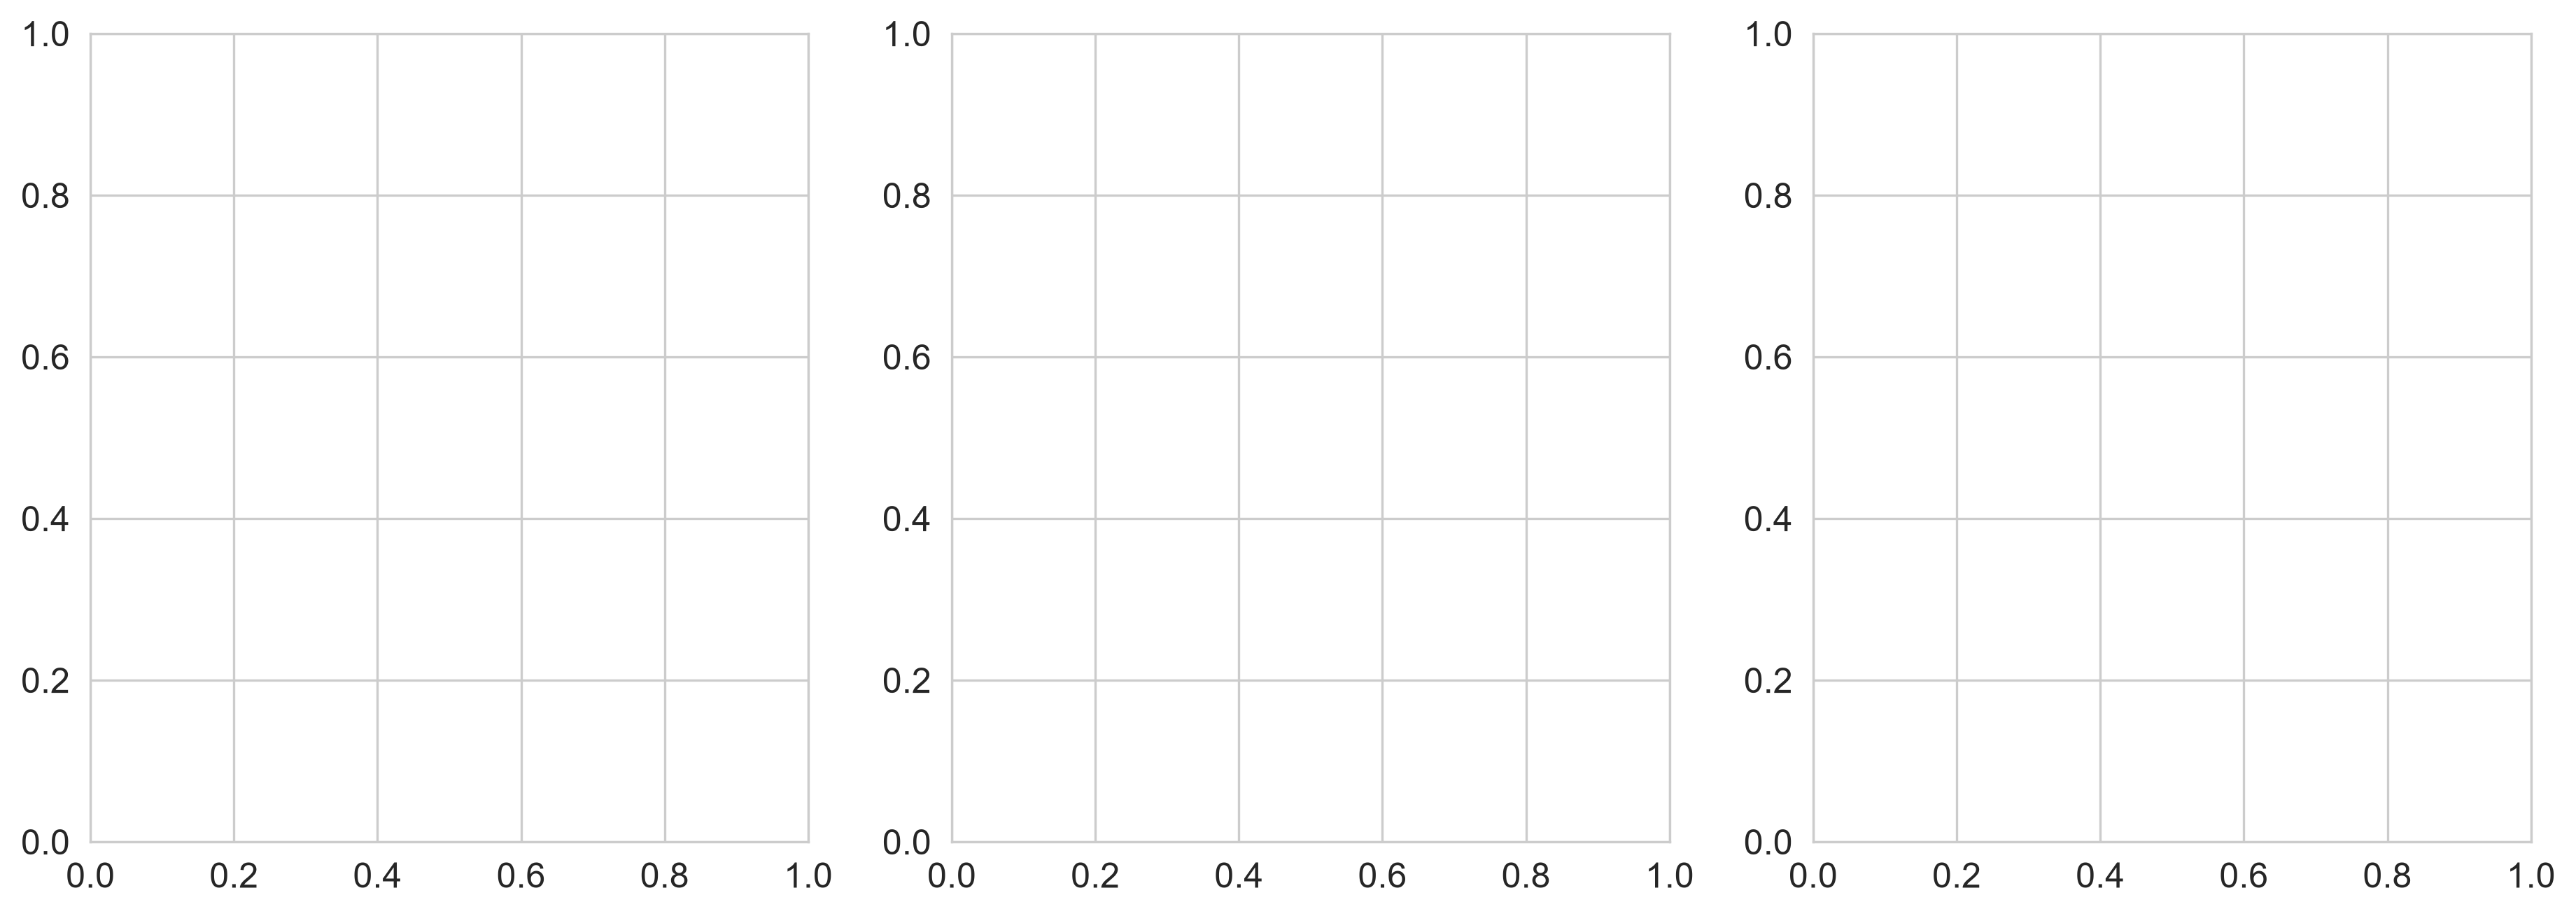

<Figure size 3600x1200 with 0 Axes>

<Figure size 3600x1200 with 0 Axes>

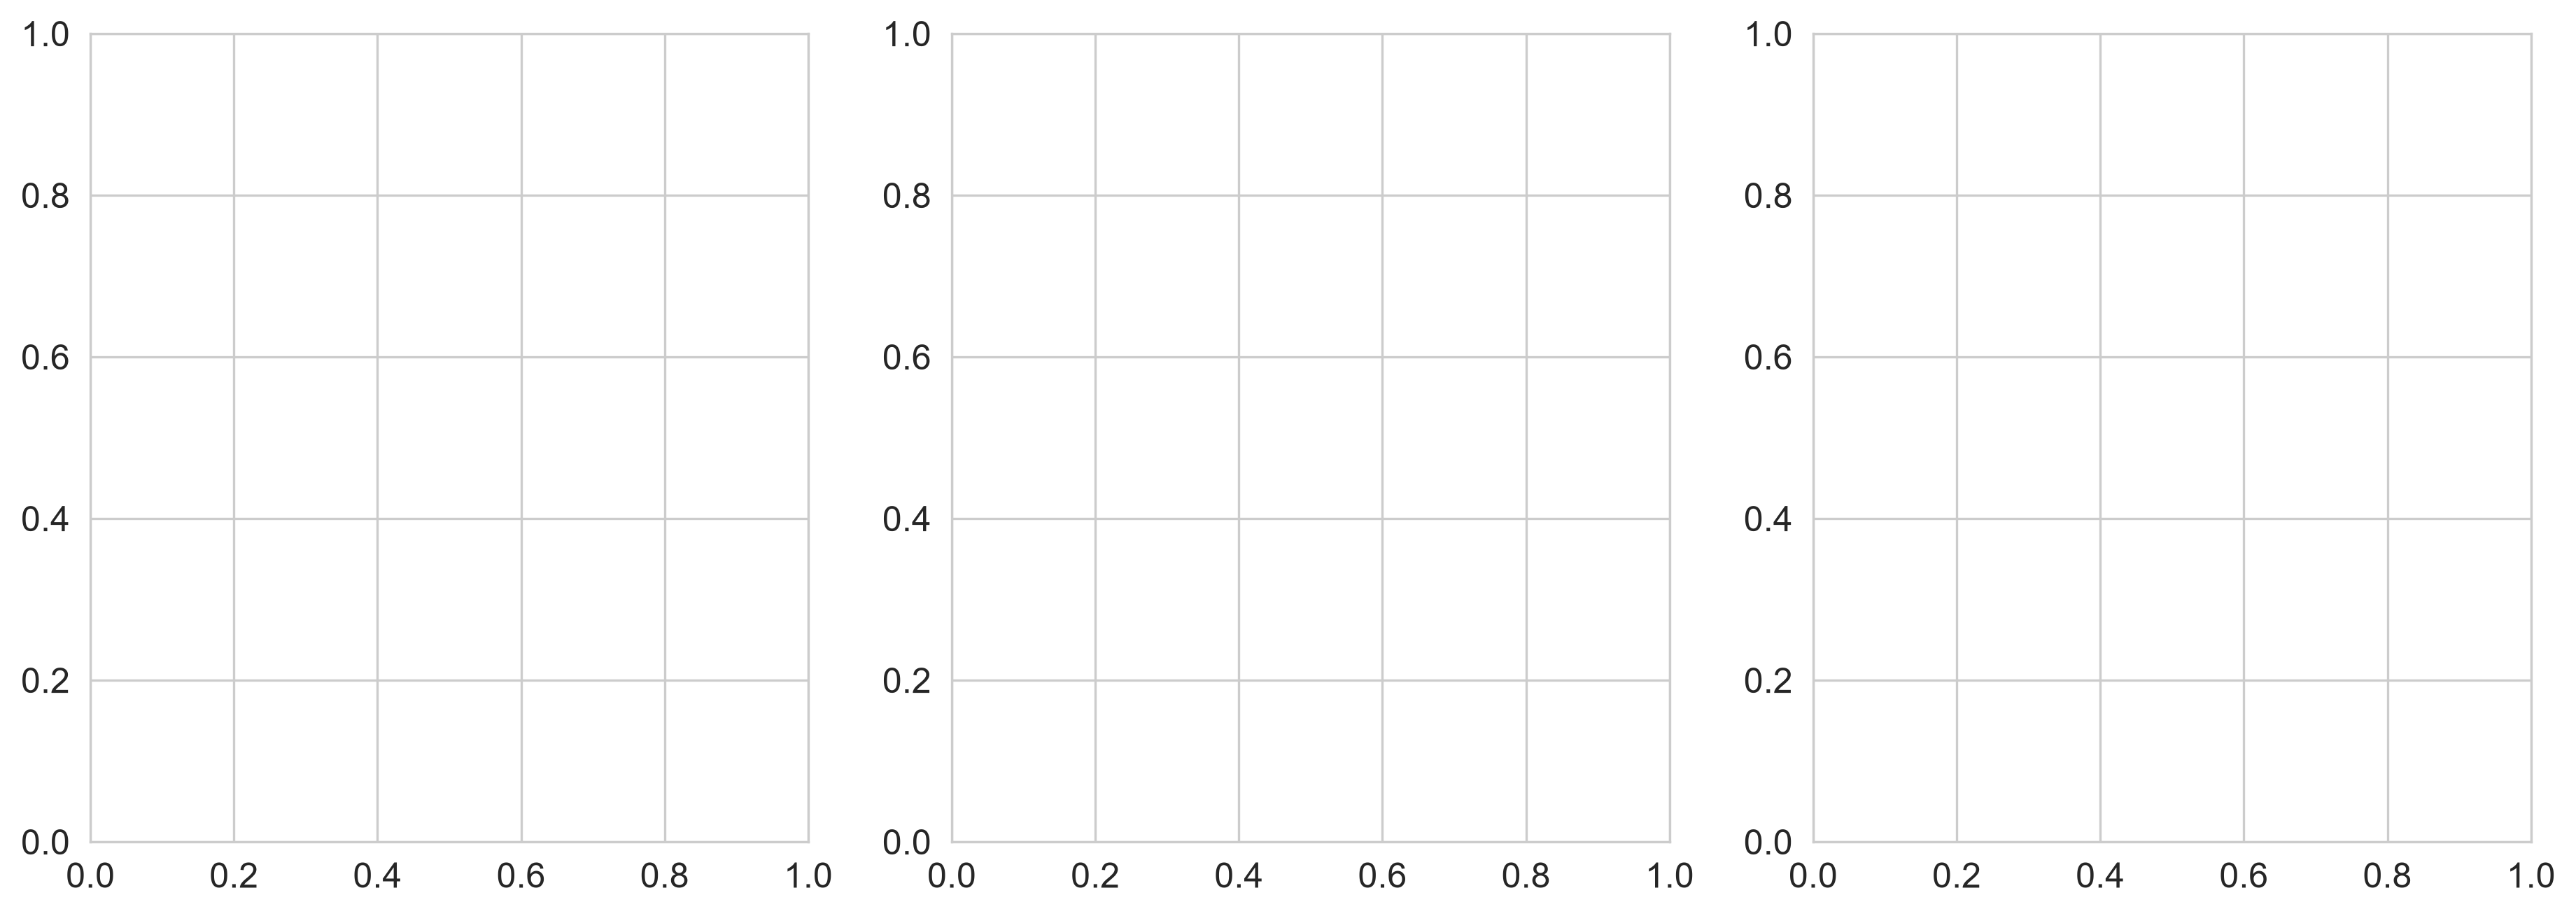

<Figure size 3600x1200 with 0 Axes>

<Figure size 3600x1200 with 0 Axes>

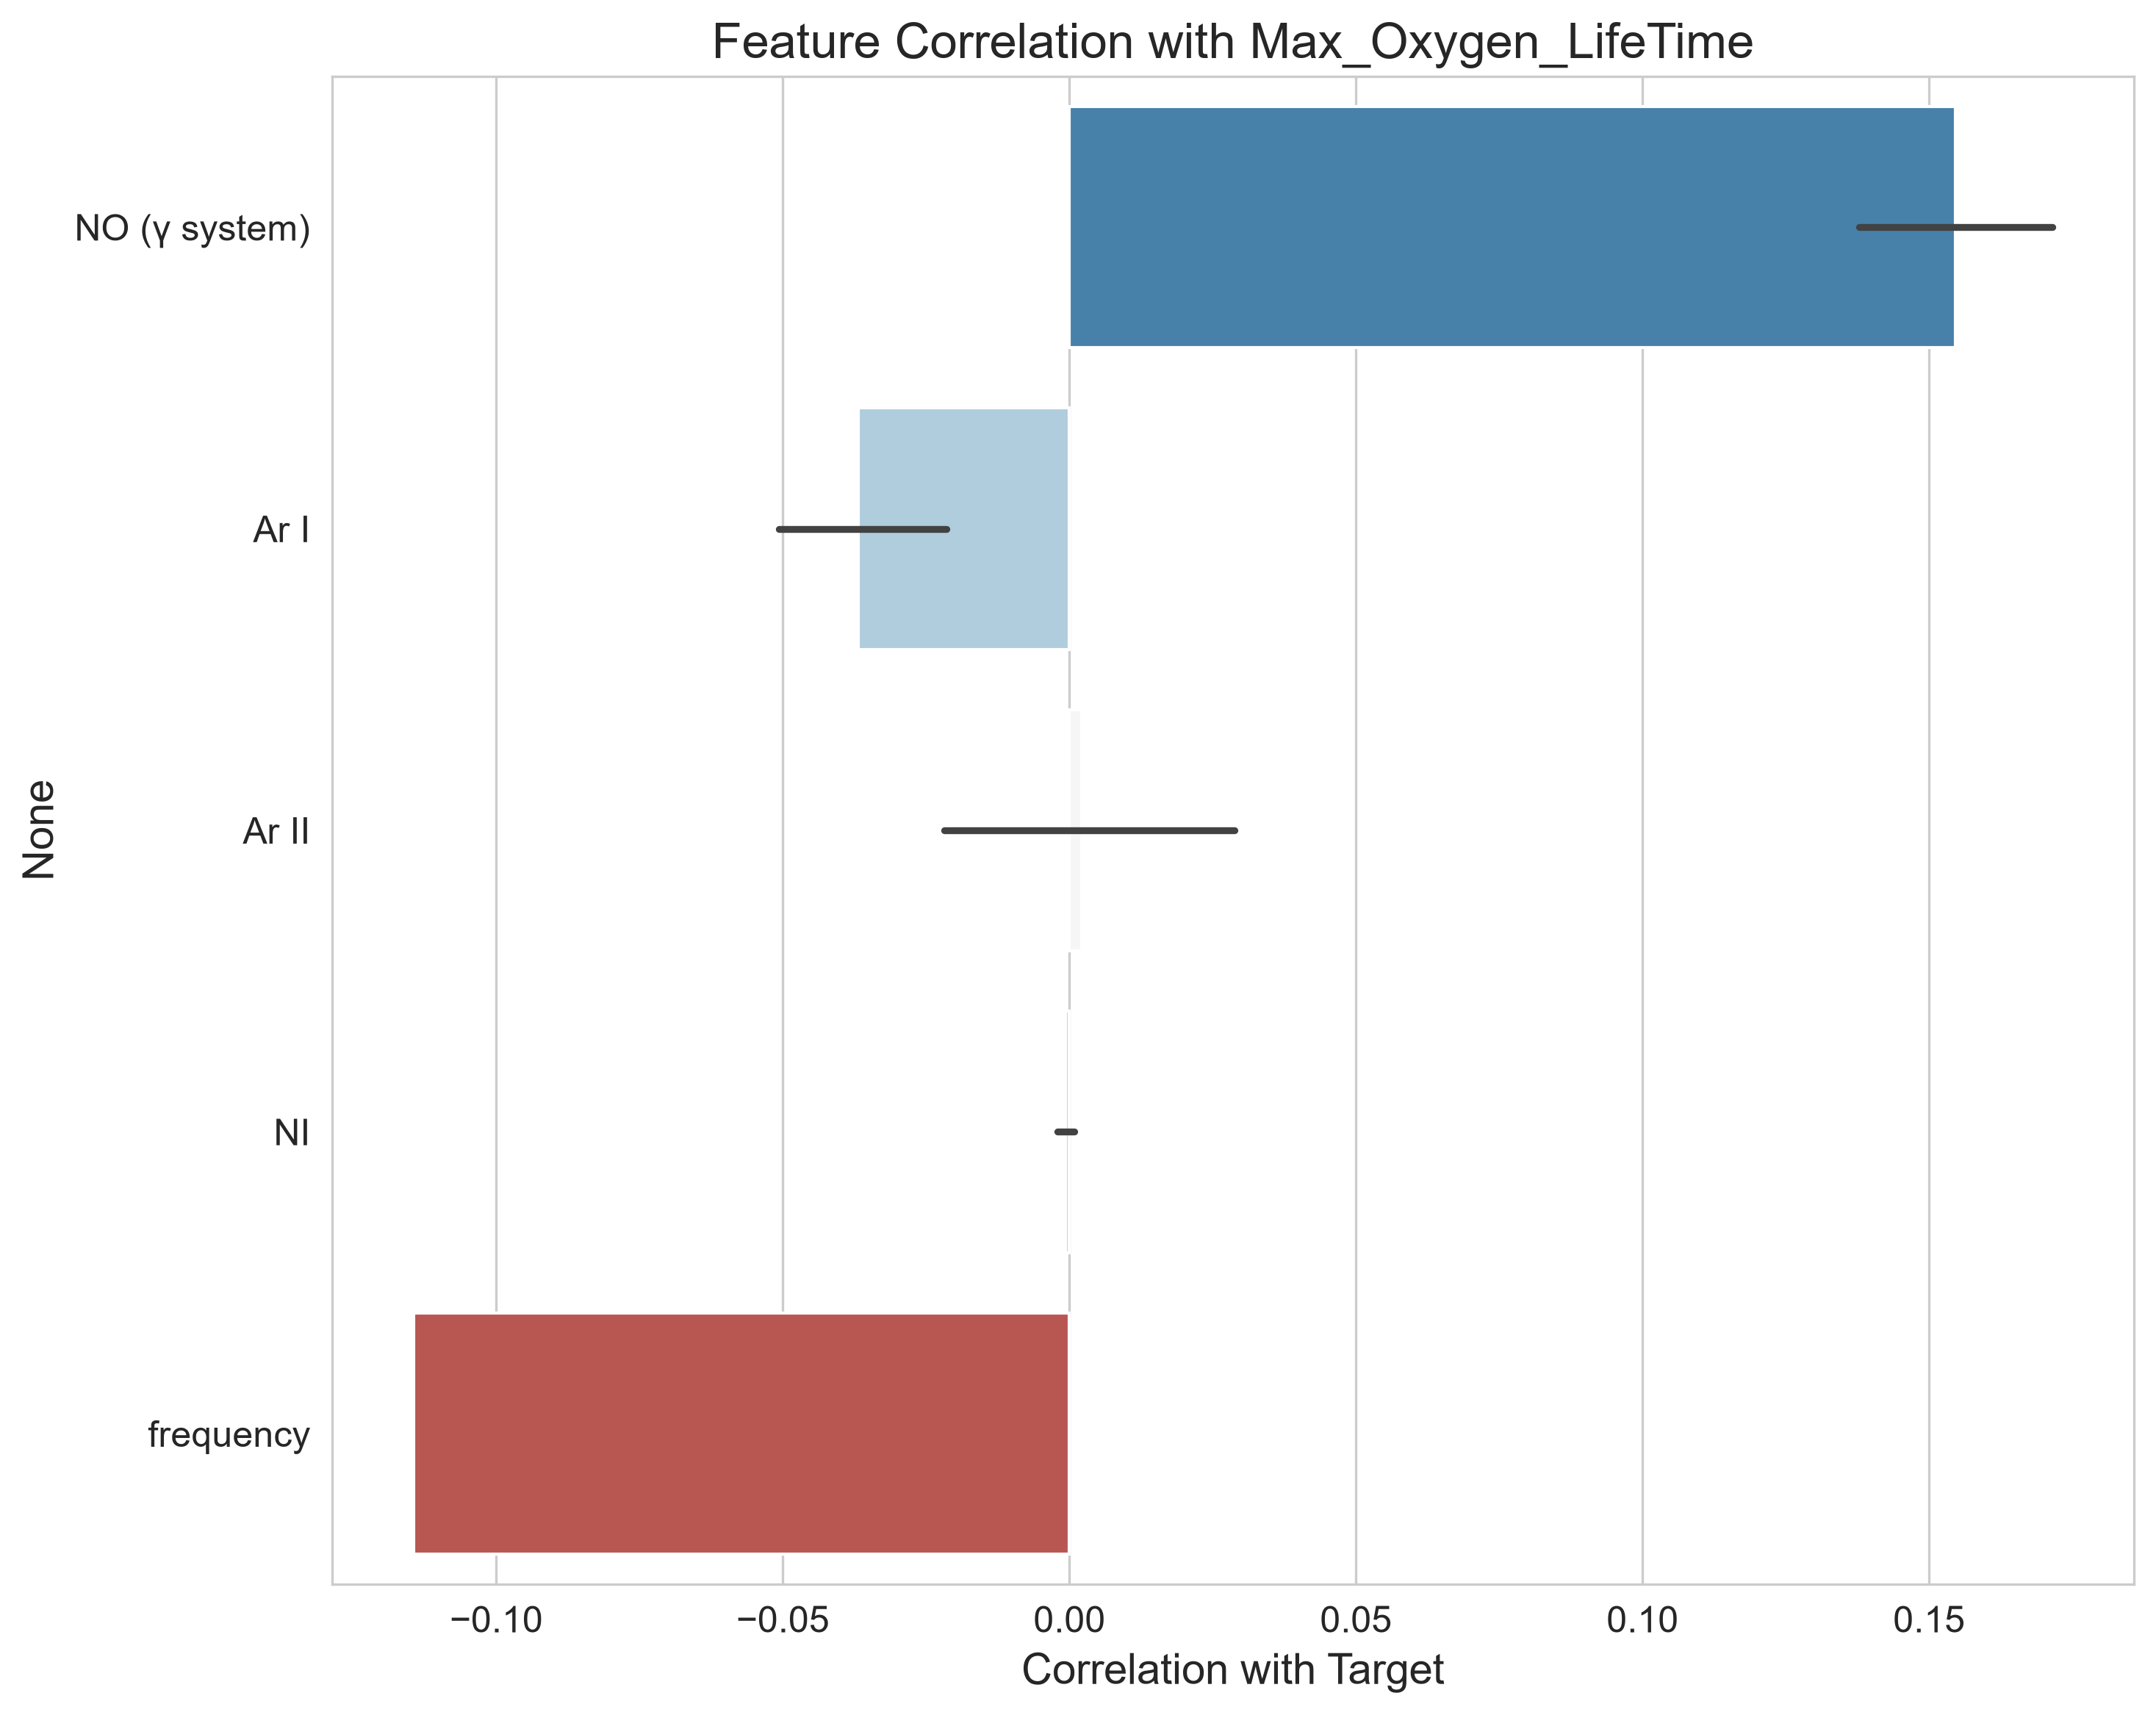

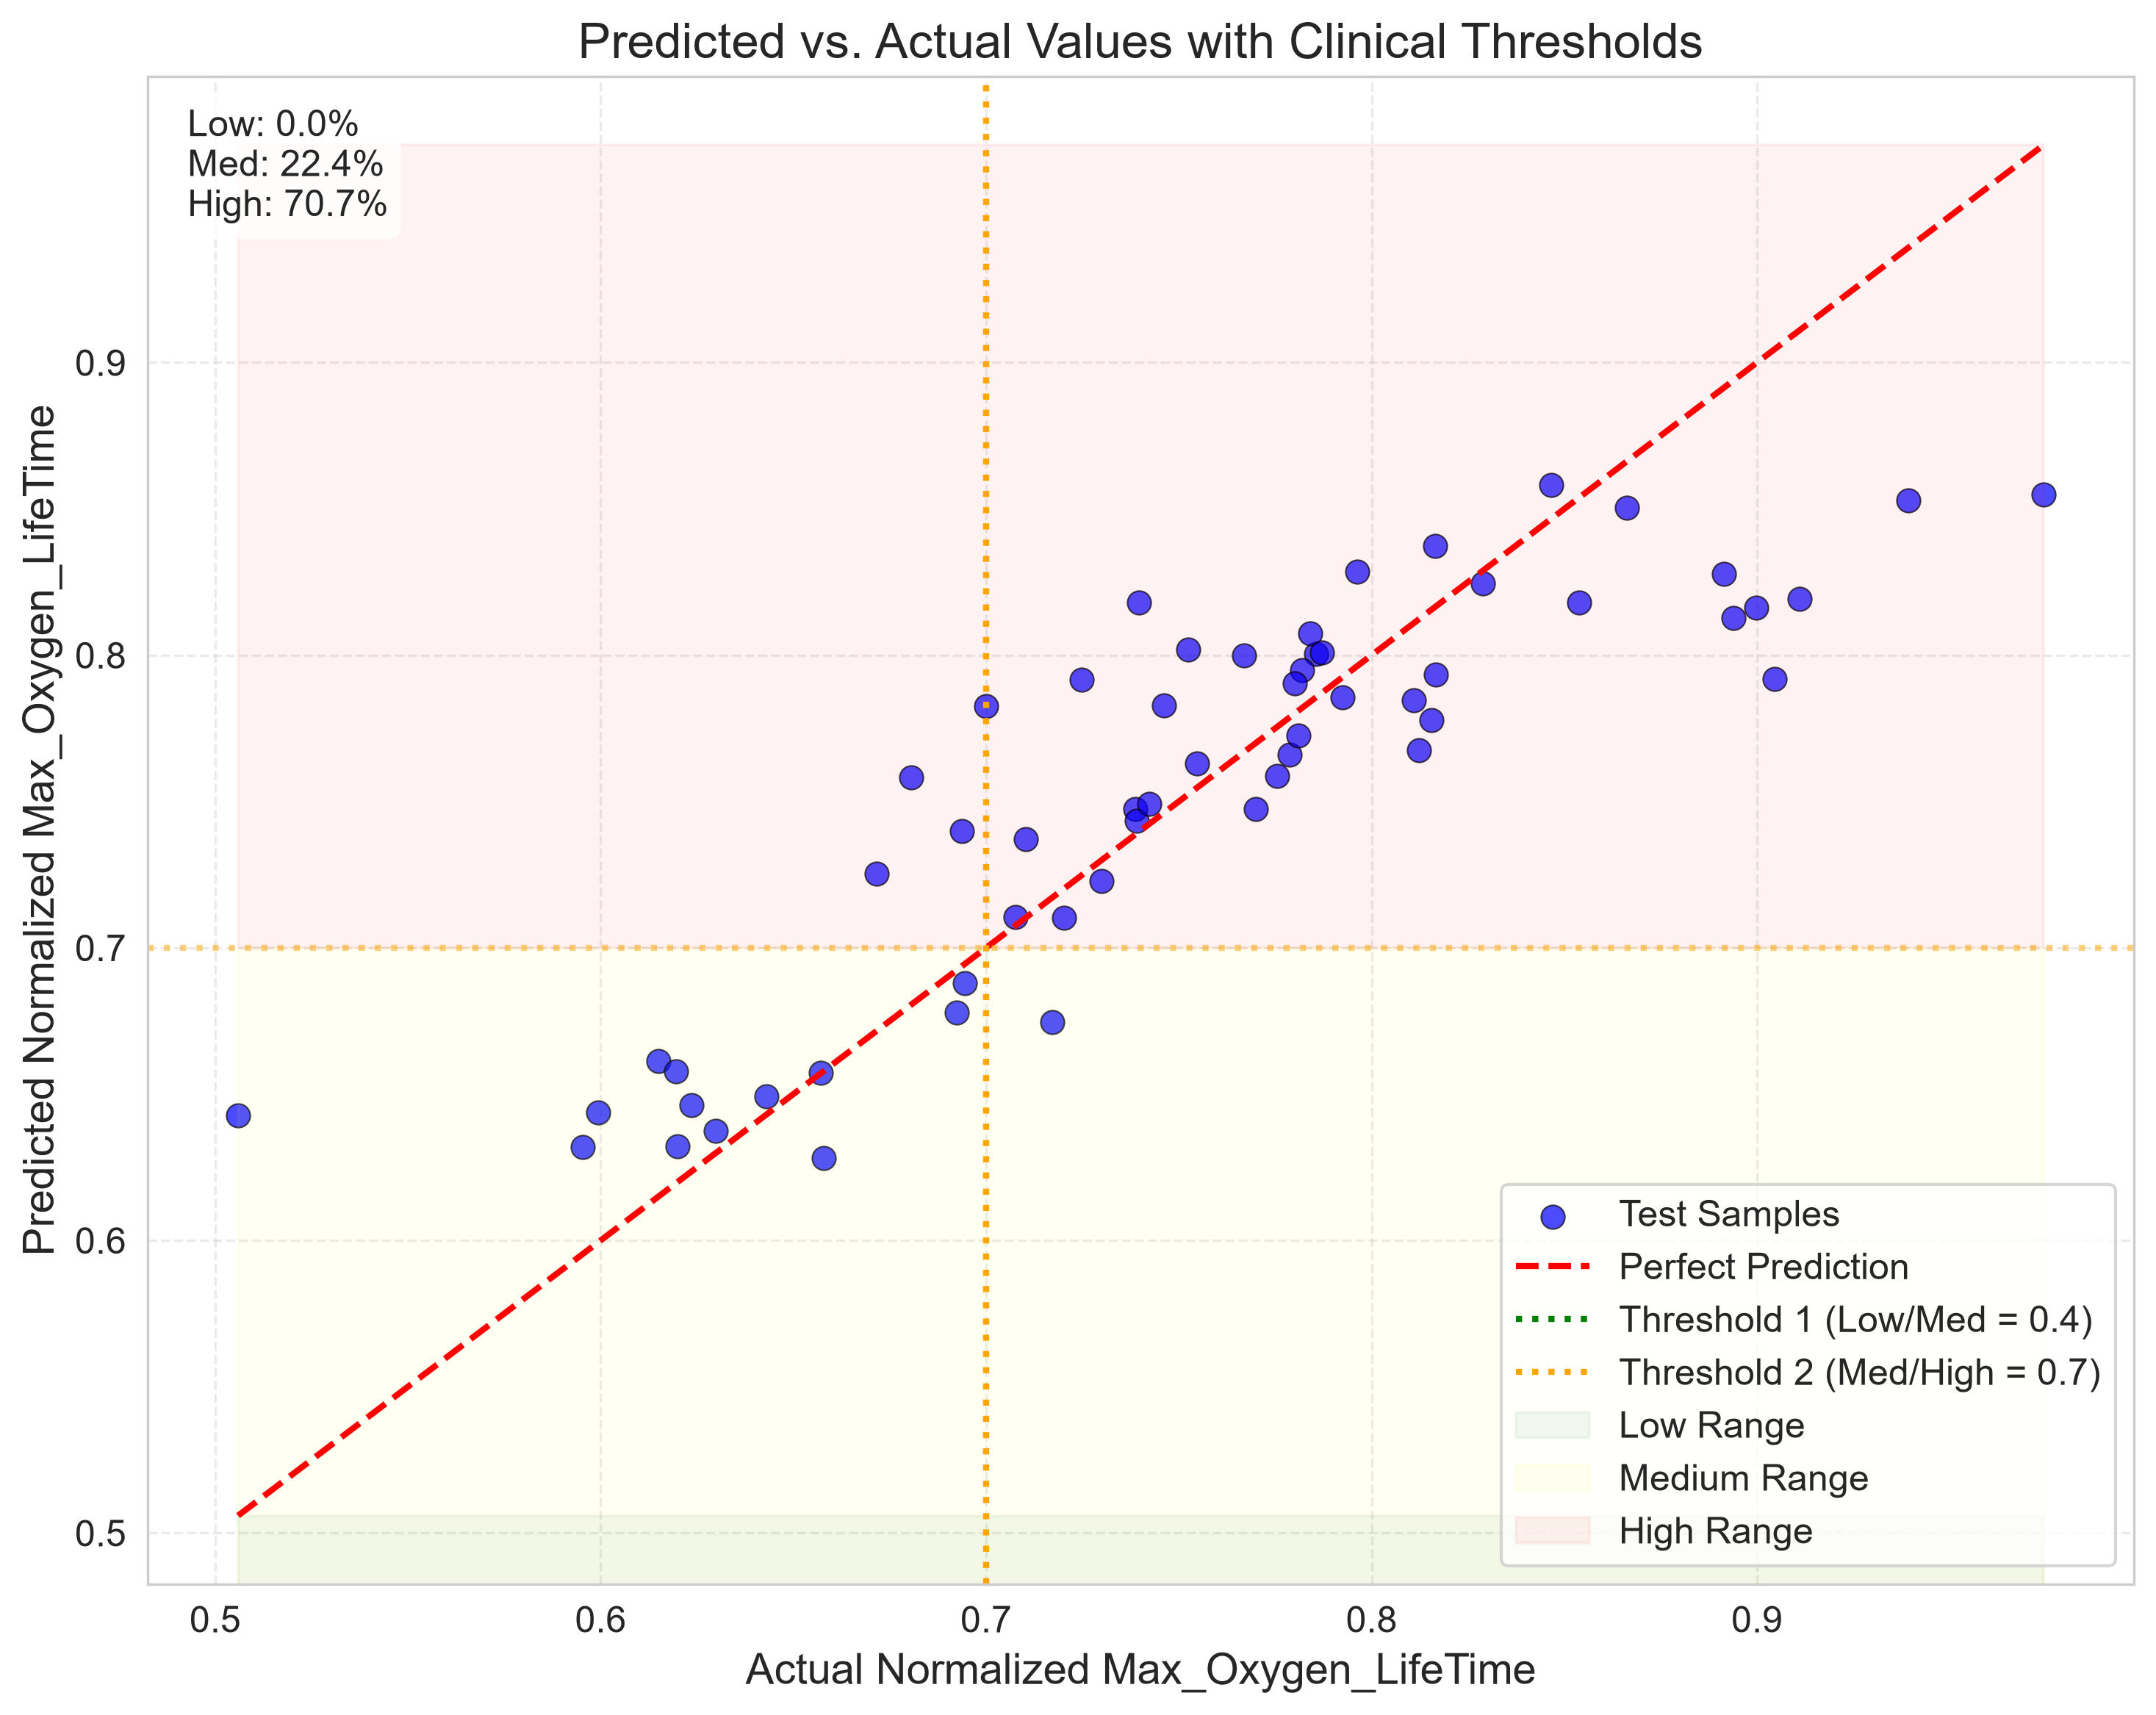


✅ Plot with thresholds saved to 'figures_species/16_predicted_vs_actual_with_thresholds.png'.


In [127]:
# ==========================================
# Predicted vs. Actual plot with diagnostic thresholds
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Appearance settings
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# --- Test data (already available) ---
# Assume y_test and y_test_pred are already defined
# Here, to be safe, we flatten them to 1D
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred.flatten()

# --- Define clinical thresholds (according to plasma physics knowledge) ---
# For example, assume:
# First threshold (low/medium) = 0.4 (normalized value)
# Second threshold (medium/high) = 0.7 (normalized value)
# You can adjust these numbers based on your knowledge or data percentiles.

threshold_low = 0.4   # e.g., minimum acceptable lifespan
threshold_high = 0.7  # e.g., very high lifespan

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Scatter points (samples)
# Coloring based on actual range (optional) or uniform
scatter = ax.scatter(
    y_test_flat, y_test_pred_flat,
    c='blue',             # Point color
    alpha=0.7,            # Transparency
    edgecolors='k',       # Black border for clarity
    linewidth=0.5,
    s=60,                 # Point size
    label='Test Samples'
)

# 2. Ideal line (Perfect Prediction) - red
min_val = min(y_test_flat.min(), y_test_pred_flat.min())
max_val = max(y_test_flat.max(), y_test_pred_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# 3. Vertical threshold lines
ax.axvline(x=threshold_low, color='green', linestyle=':', linewidth=2, label=f'Threshold 1 (Low/Med = {threshold_low})')
ax.axvline(x=threshold_high, color='orange', linestyle=':', linewidth=2, label=f'Threshold 2 (Med/High = {threshold_high})')

# 4. Horizontal threshold lines - similar for Y-axis
ax.axhline(y=threshold_low, color='green', linestyle=':', linewidth=2, alpha=0.5)
ax.axhline(y=threshold_high, color='orange', linestyle=':', linewidth=2, alpha=0.5)

# 5. Filling regions (optional - for better aesthetics)
# Low region
ax.fill_betweenx([min_val, threshold_low], min_val, max_val, color='green', alpha=0.05, label='Low Range')
# Medium region
ax.fill_betweenx([threshold_low, threshold_high], min_val, max_val, color='yellow', alpha=0.05, label='Medium Range')
# High region
ax.fill_betweenx([threshold_high, max_val], min_val, max_val, color='red', alpha=0.05, label='High Range')

# 6. Axis and label settings
ax.set_xlabel('Actual Normalized Max_Oxygen_LifeTime', fontsize=14)
ax.set_ylabel('Predicted Normalized Max_Oxygen_LifeTime', fontsize=14)
ax.set_title('Predicted vs. Actual Values with Clinical Thresholds', fontsize=16)

# Set axis limits with a 5% margin
margin = 0.05 * (max_val - min_val)
ax.set_xlim([min_val - margin, max_val + margin])
ax.set_ylim([min_val - margin, max_val + margin])

# 7. Display percentage of points in each region (optional, for more info)
total = len(y_test_flat)
low_region = np.sum((y_test_flat < threshold_low) & (y_test_pred_flat < threshold_low))
med_region = np.sum((y_test_flat >= threshold_low) & (y_test_flat < threshold_high) & 
                    (y_test_pred_flat >= threshold_low) & (y_test_pred_flat < threshold_high))
high_region = np.sum((y_test_flat >= threshold_high) & (y_test_pred_flat >= threshold_high))

# Add text in the corner of the plot
textstr = f'Low: {low_region/total*100:.1f}%\nMed: {med_region/total*100:.1f}%\nHigh: {high_region/total*100:.1f}%'
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

# 8. Legend
ax.legend(loc='lower right', fontsize=12)

# 9. Background grid (optional)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("figures_species/16_predicted_vs_actual_with_thresholds.png", bbox_inches='tight')
plt.show()

print("\n✅ Plot with thresholds saved to 'figures_species/16_predicted_vs_actual_with_thresholds.png'.")

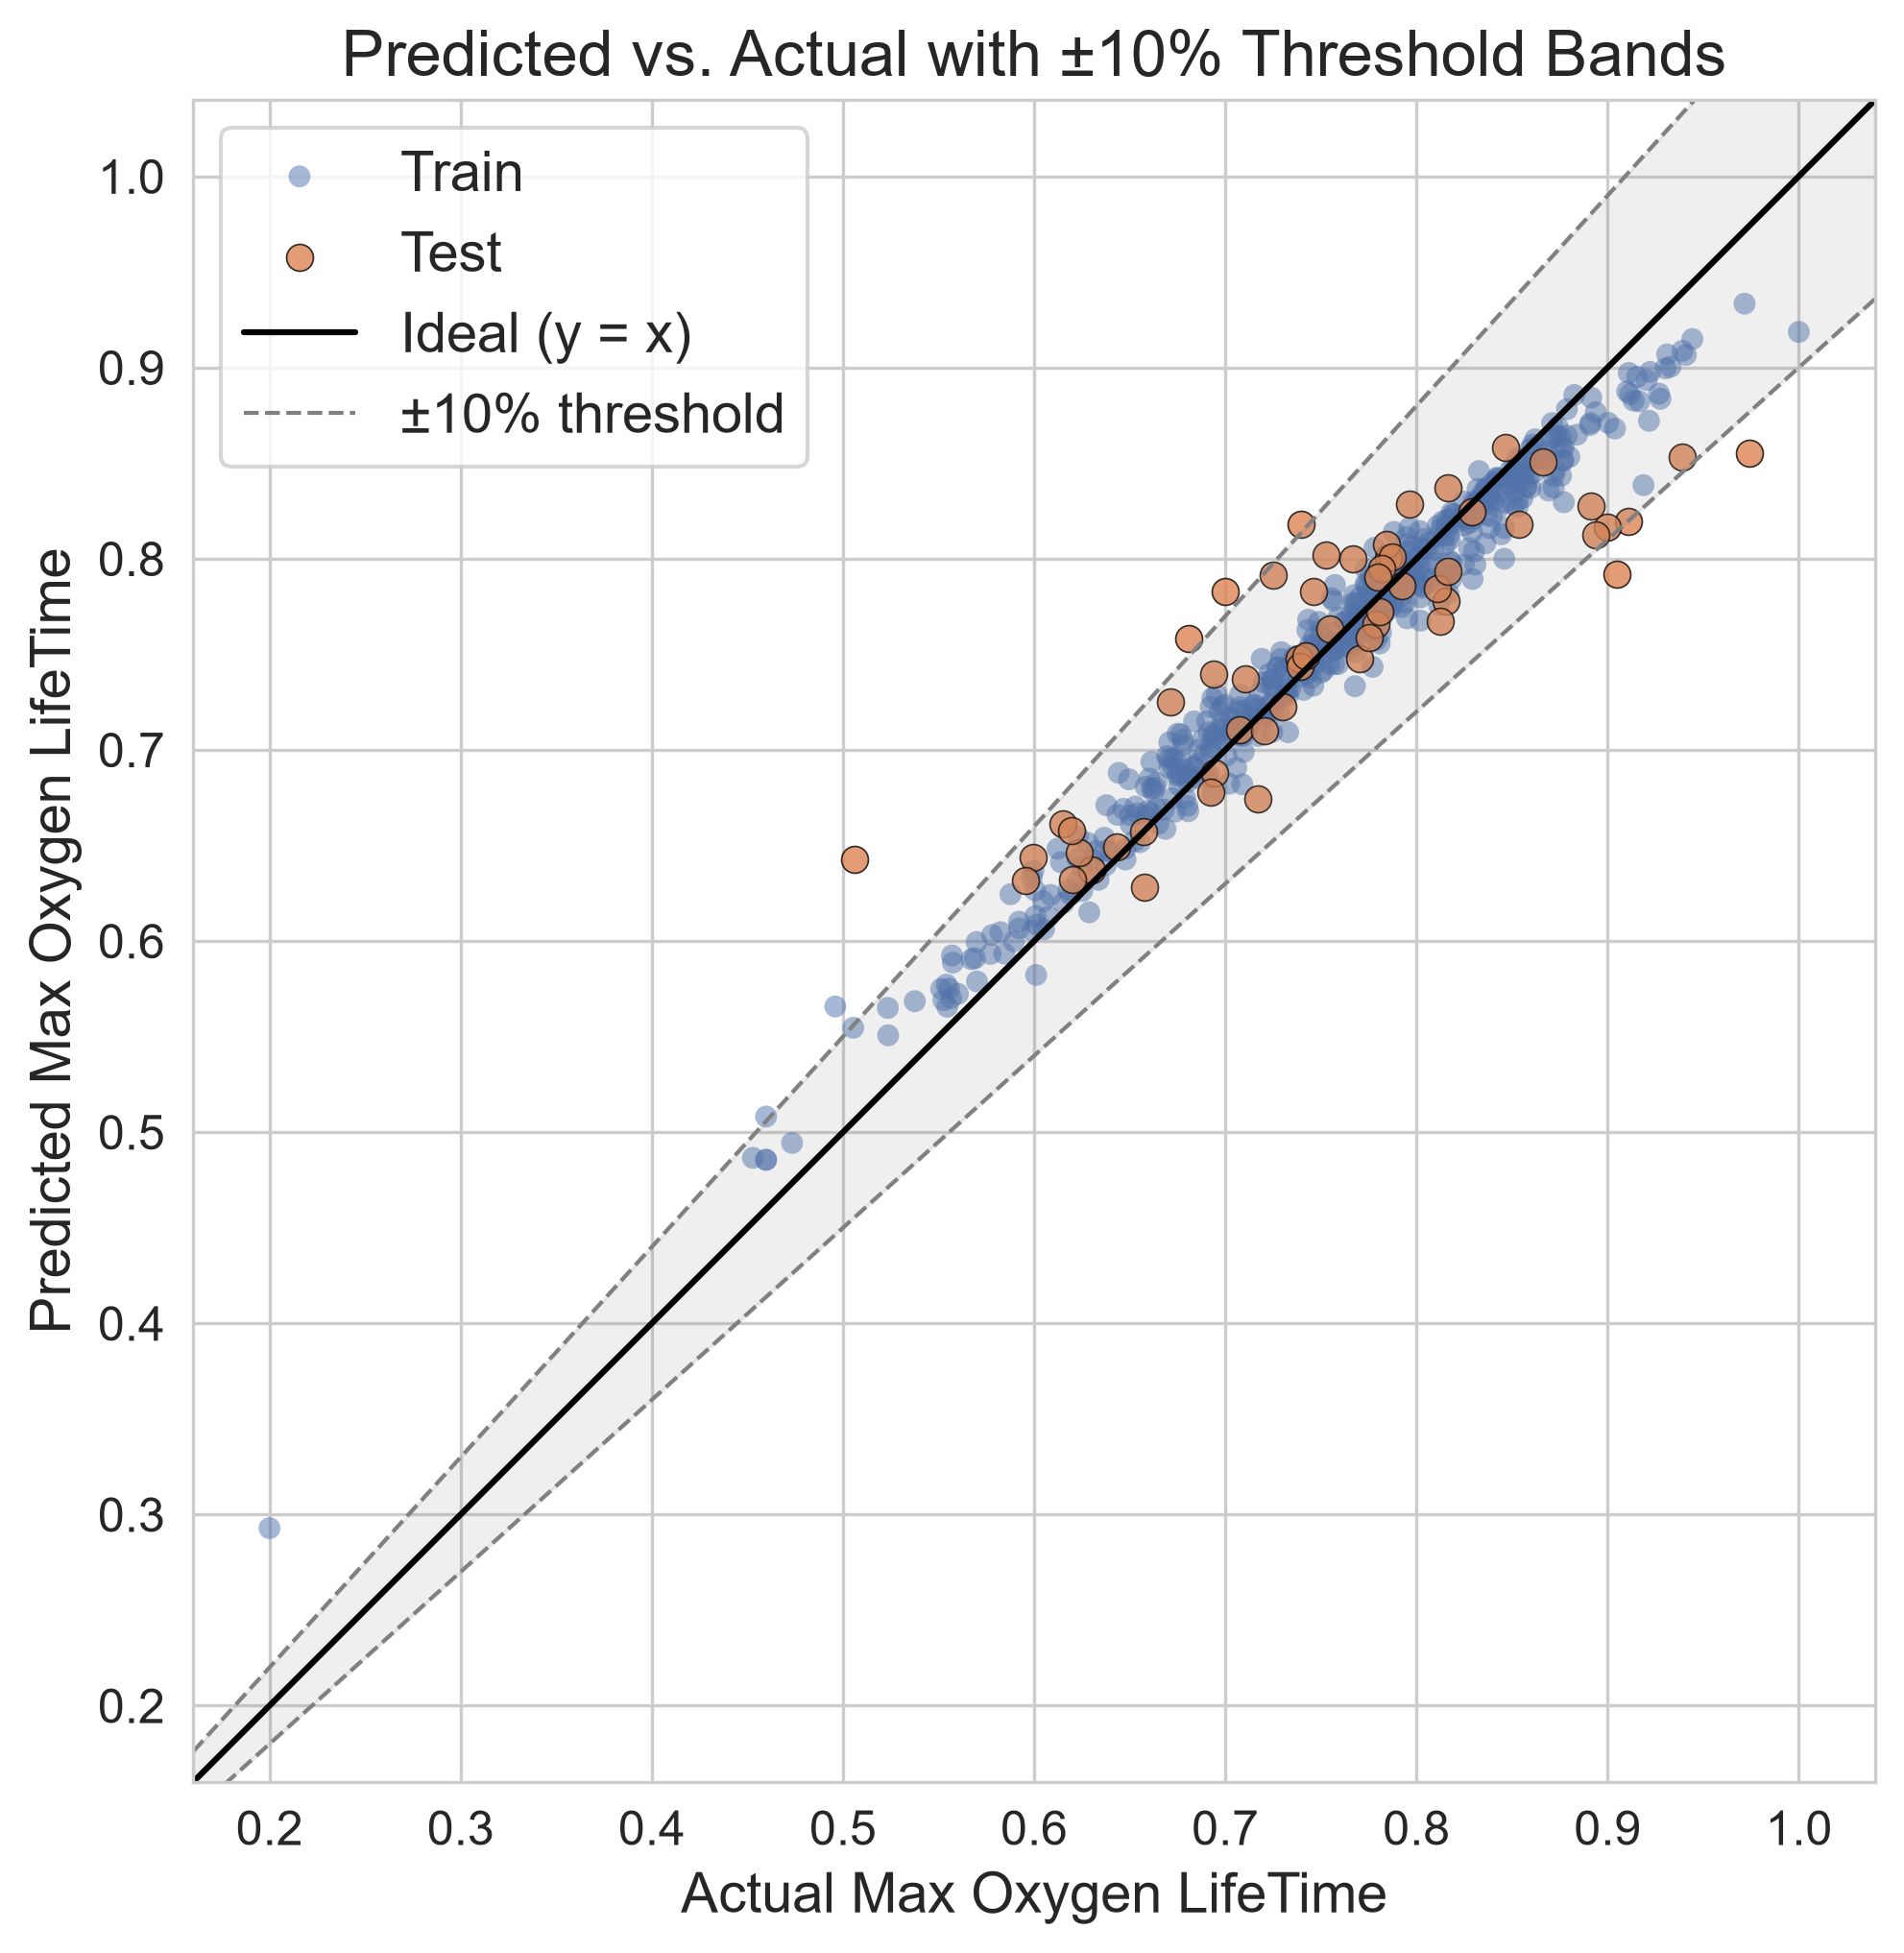

Test points within ±10% threshold: 1624/58 (48.3%)


In [128]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Plot 16: Predicted vs. Actual with threshold bands
# ============================================================

THRESHOLD_PCT = 0.10   # ±10% error band — change to taste


# ---------------------------------------------------------------
# 2. Plot
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_train, y_train_pred, alpha=0.5, s=30,
           label="Train", color="#4C72B0", edgecolor="none")
ax.scatter(y_test, y_test_pred, alpha=0.8, s=45,
           label="Test", color="#DD8452", edgecolor="black", linewidth=0.4)

# 1:1 reference line, spanning both actual and predicted ranges
all_actual = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_train_pred, y_test_pred])
lo = min(all_actual.min(), all_pred.min())
hi = max(all_actual.max(), all_pred.max())
pad = 0.05 * (hi - lo)
line_x = np.linspace(lo - pad, hi + pad, 100)

ax.plot(line_x, line_x, color="black", linewidth=1.5, label="Ideal (y = x)")

# ±THRESHOLD_PCT bands around the 1:1 line
ax.plot(line_x, line_x * (1 + THRESHOLD_PCT), color="gray",
        linestyle="--", linewidth=1, label=f"±{int(THRESHOLD_PCT*100)}% threshold")
ax.plot(line_x, line_x * (1 - THRESHOLD_PCT), color="gray",
        linestyle="--", linewidth=1)
ax.fill_between(line_x, line_x * (1 - THRESHOLD_PCT), line_x * (1 + THRESHOLD_PCT),
                 color="gray", alpha=0.12)

ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel("Actual Max Oxygen LifeTime")
ax.set_ylabel("Predicted Max Oxygen LifeTime")
ax.set_title("Predicted vs. Actual with ±10% Threshold Bands")
ax.legend(loc="upper left", frameon=True)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
# plt.savefig("saved_modelsNestedCV/16_predicted_vs_actual_with_thresholds.png",
#             dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# 3. Quick summary: % of test points within the threshold band
# ---------------------------------------------------------------
within_band_test = np.abs(y_test_pred - y_test) <= THRESHOLD_PCT * np.abs(y_test)
pct_within_test = 100 * within_band_test.mean()
print(f"Test points within ±{int(THRESHOLD_PCT*100)}% threshold: "
      f"{within_band_test.sum()}/{len(y_test)} ({pct_within_test:.1f}%)")

100%|██████████| 58/58 [00:05<00:00, 11.07it/s]


✅ SHAP values calculated.


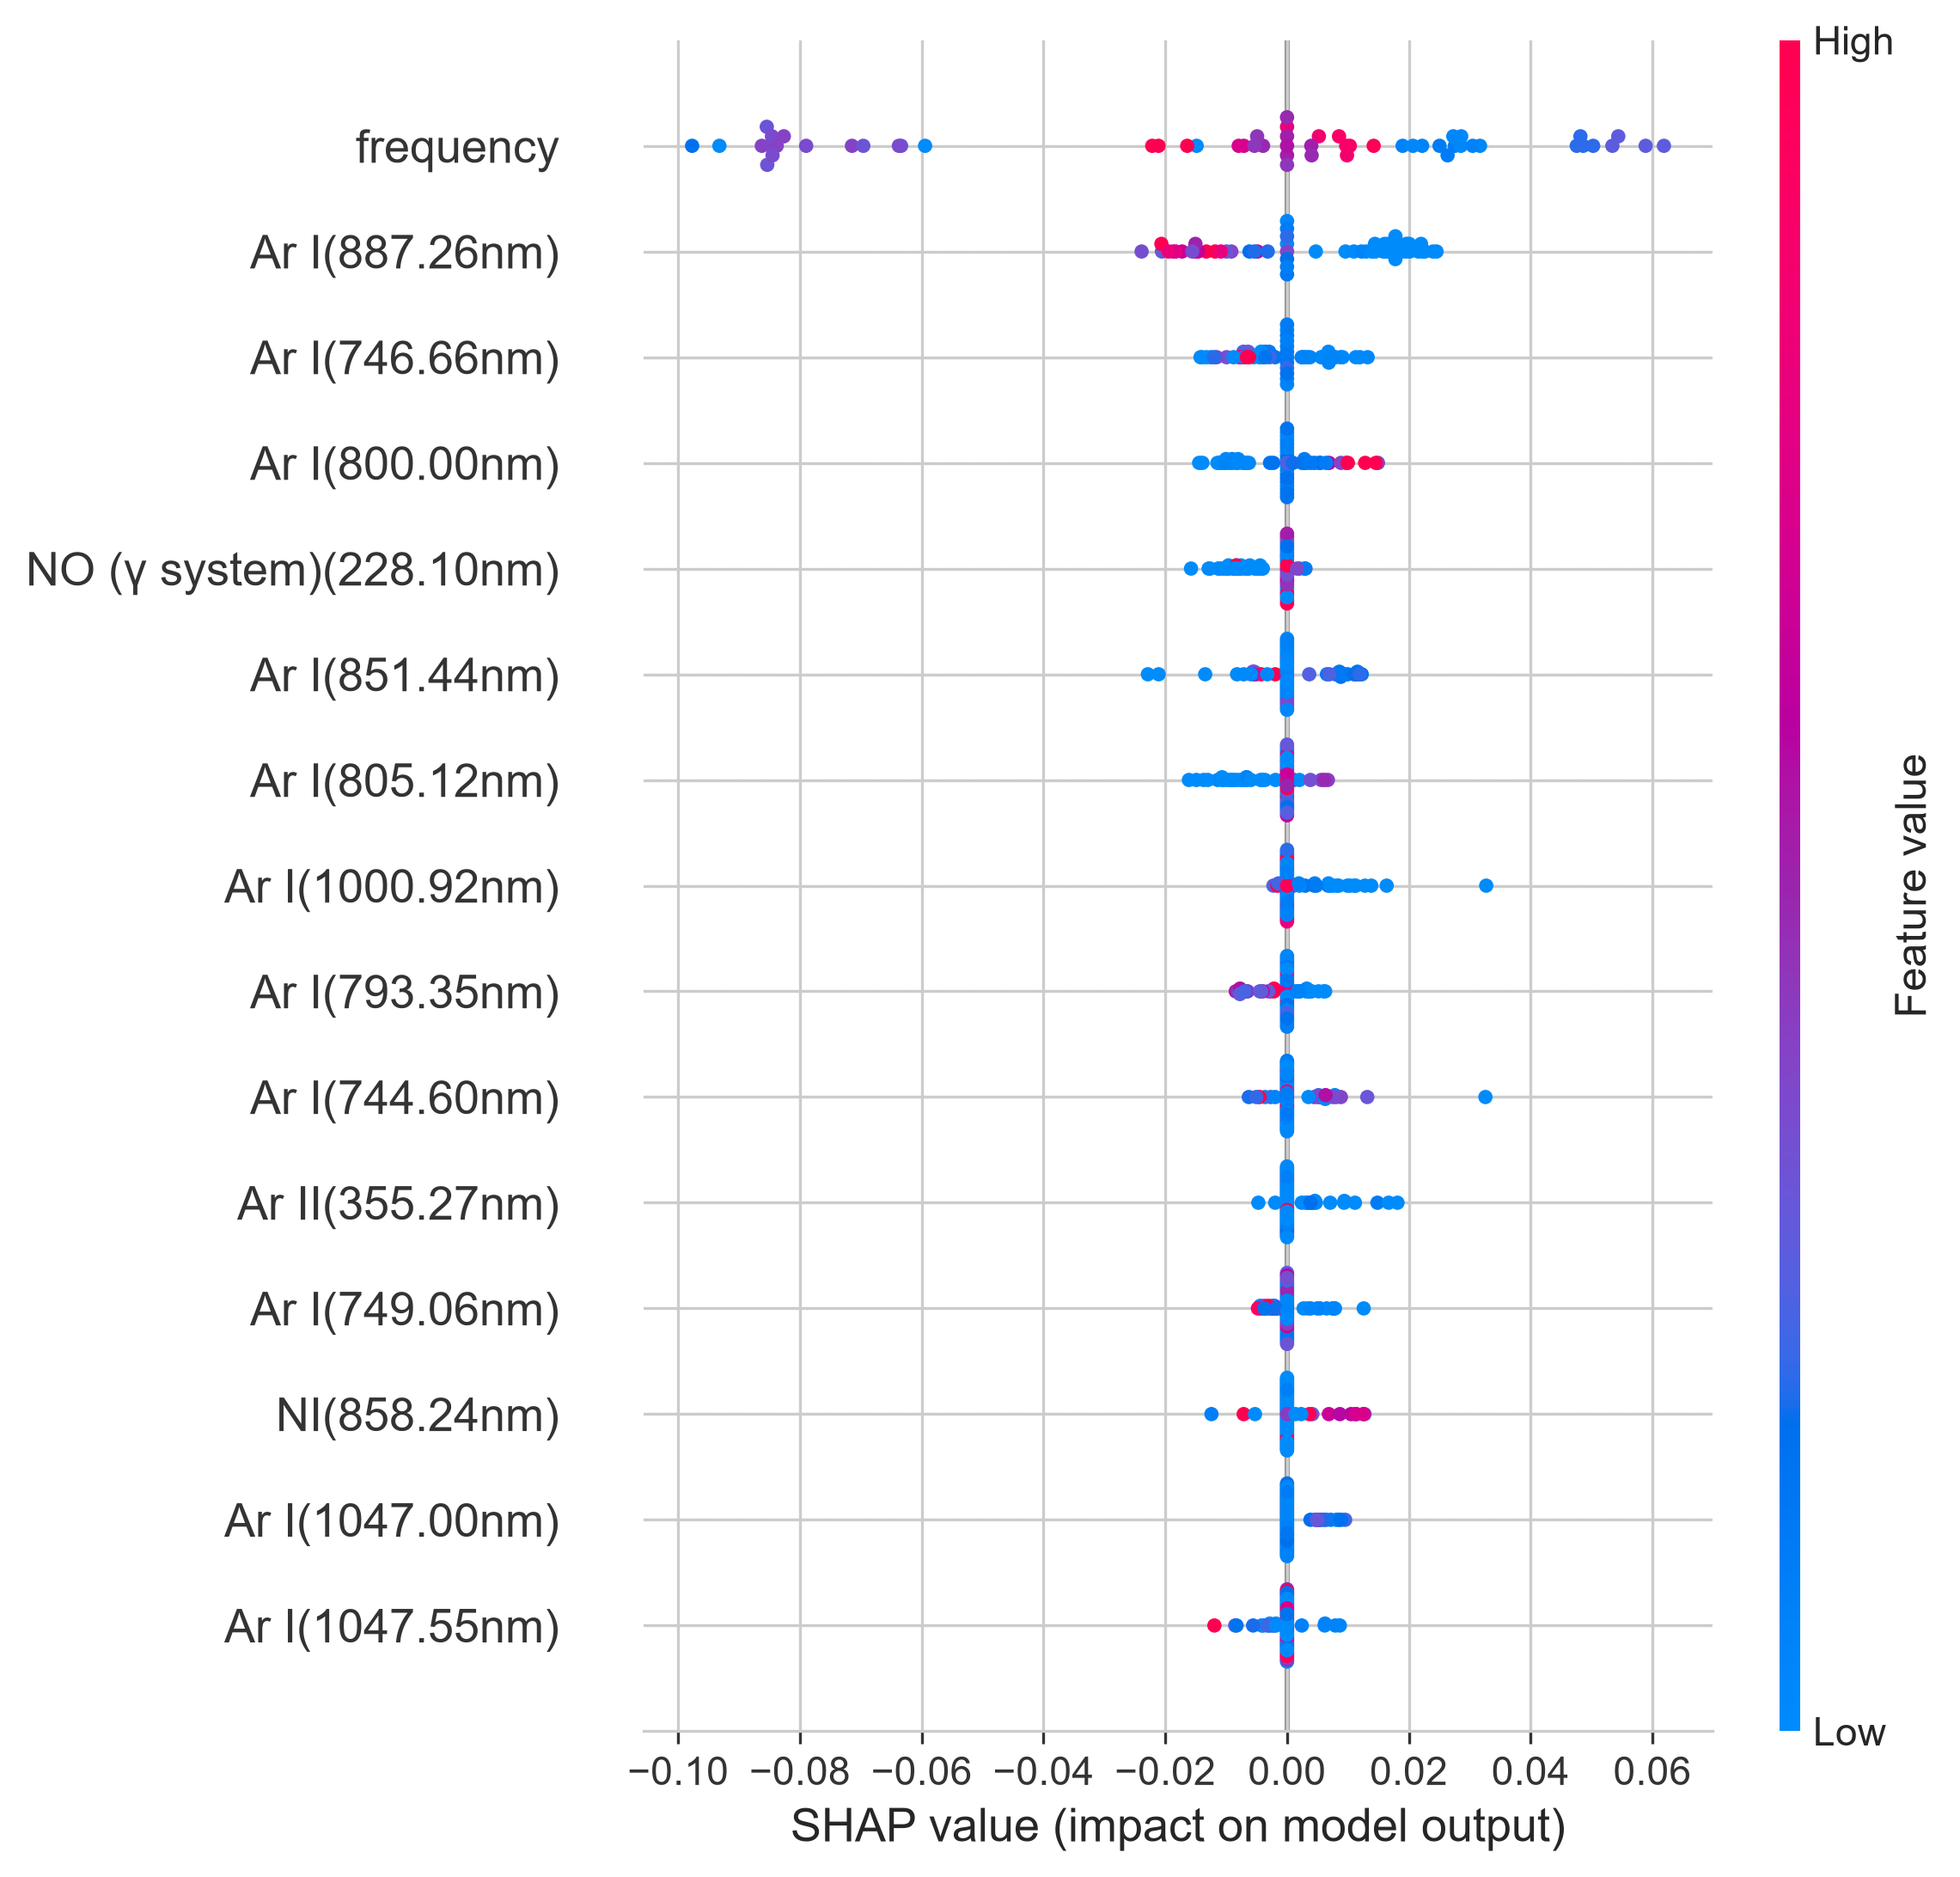

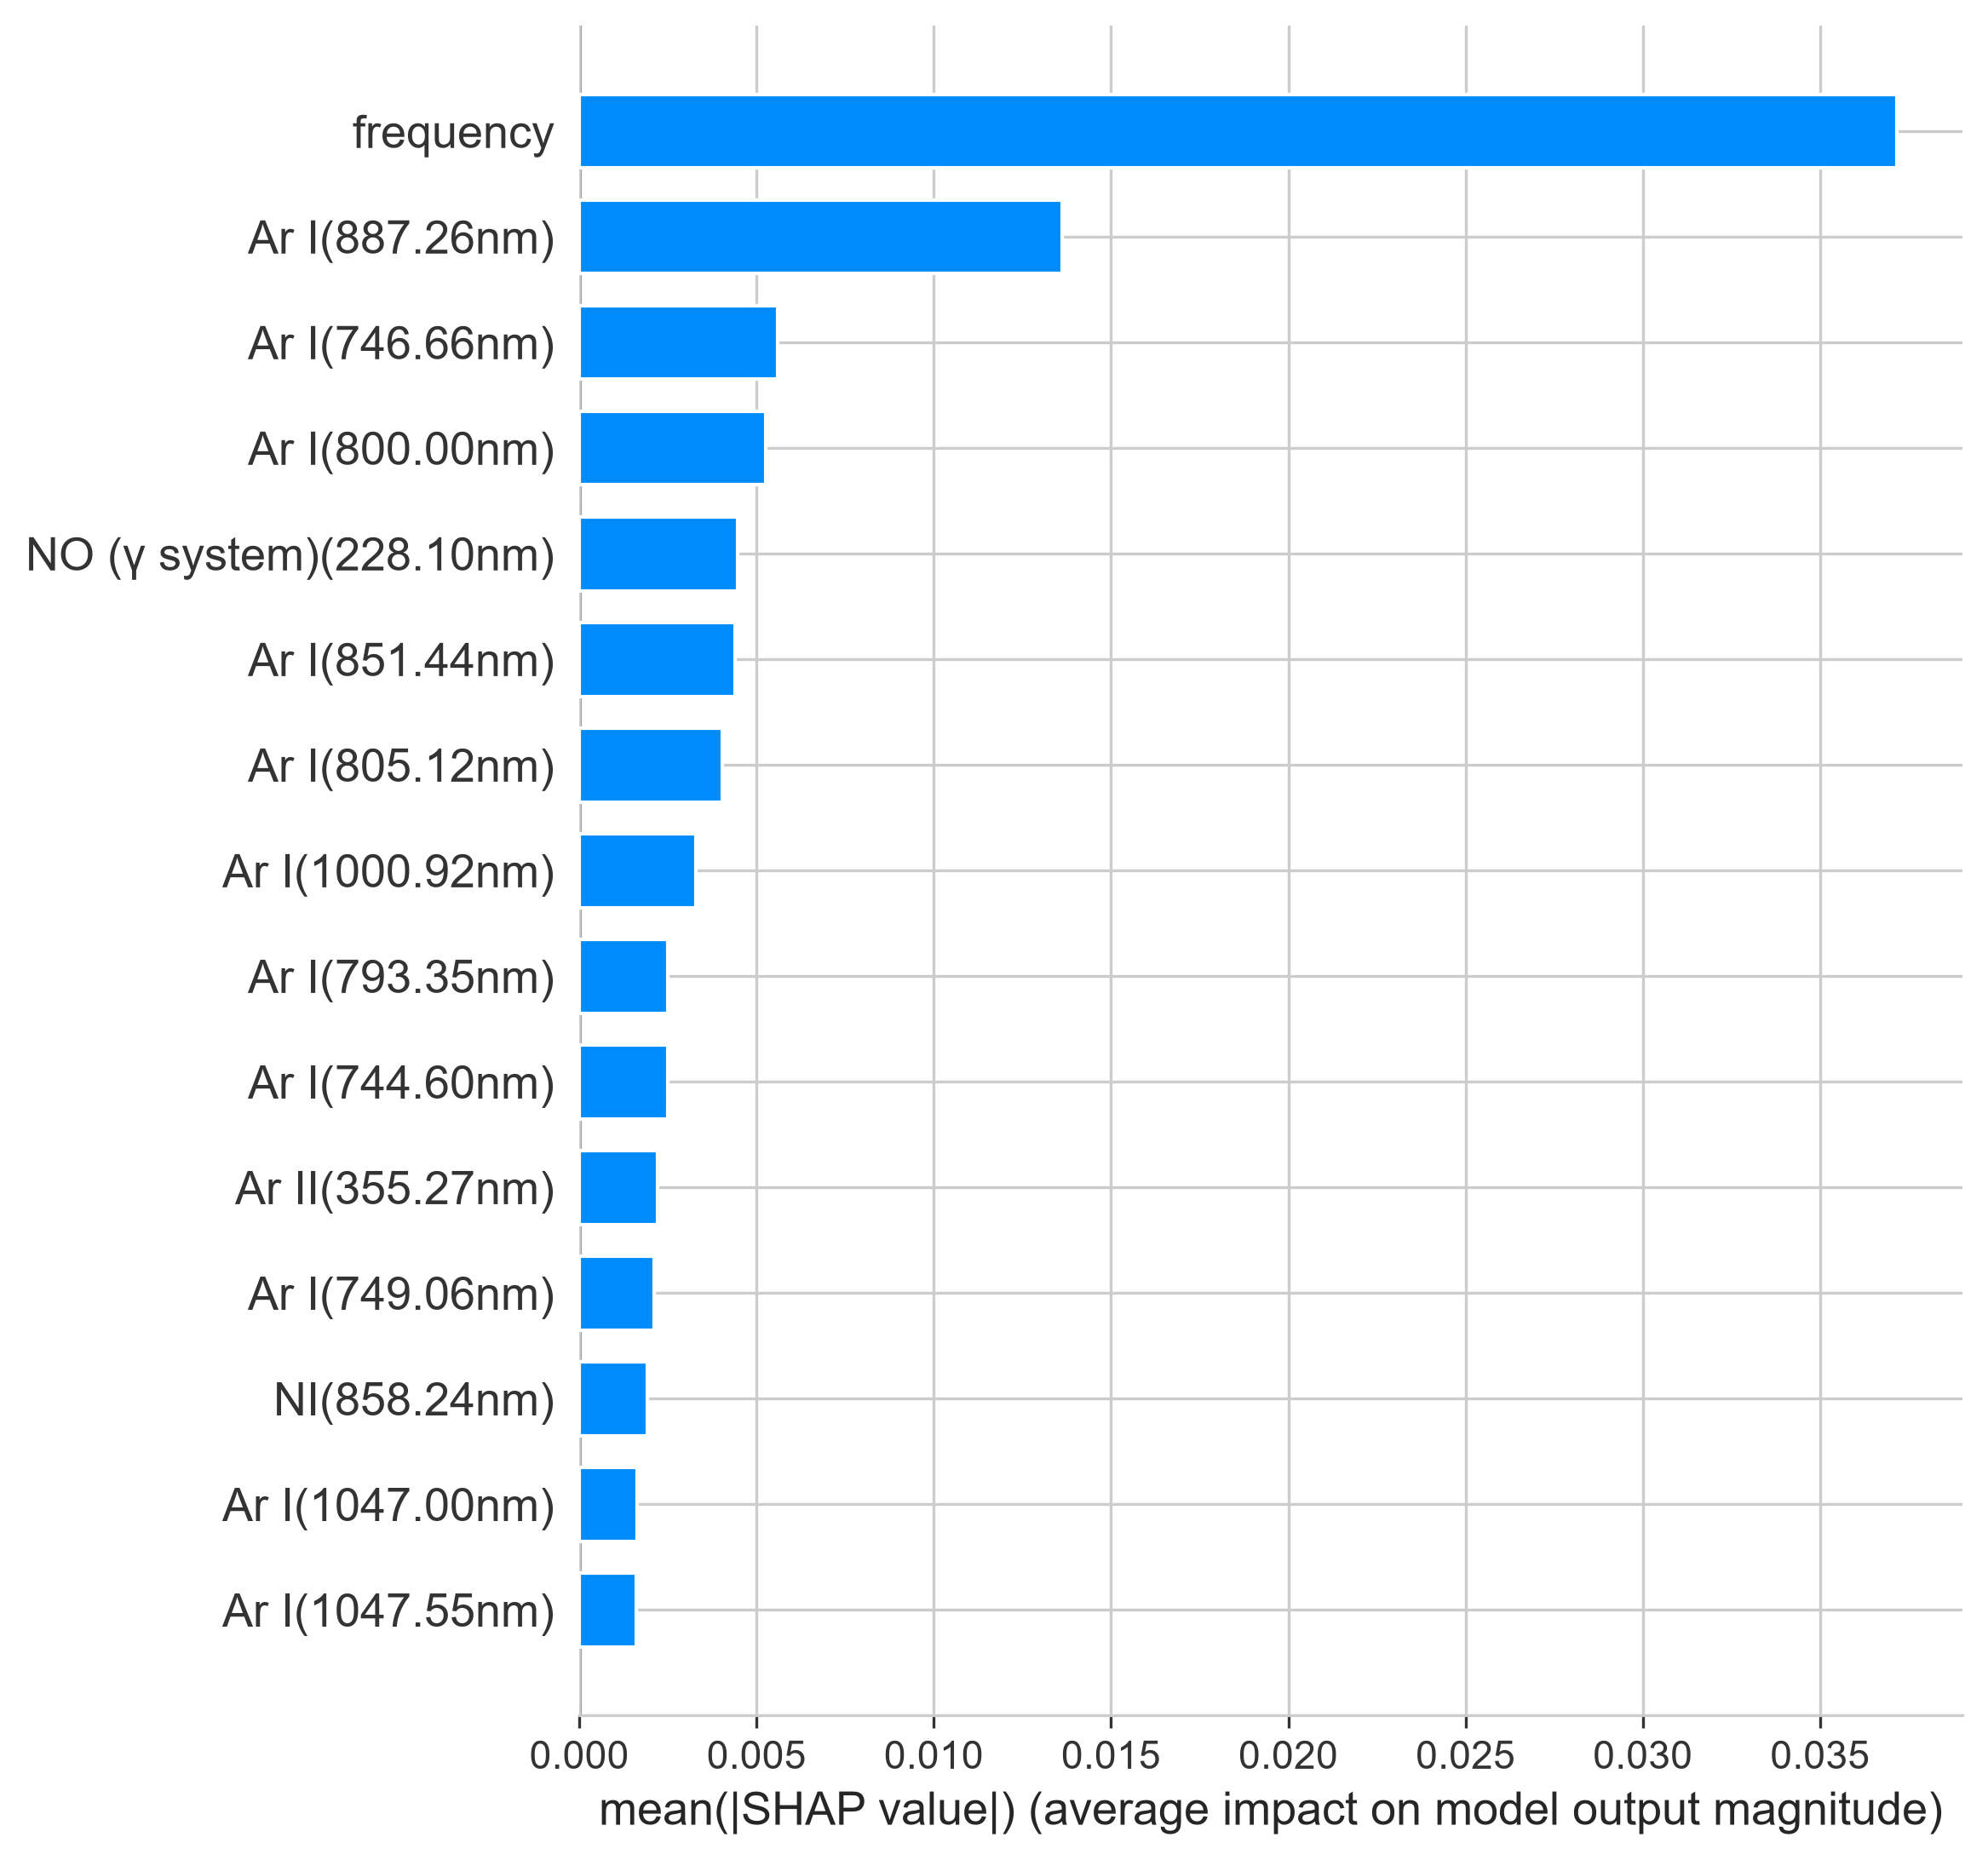


✅ All SHAP plots saved in the 'figures' folder.


In [129]:
import shap
import matplotlib.pyplot as plt
import numpy as np


# Aesthetic settings for the paper
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Feature names
feature_names = df5.drop(columns="Max_Oxygen_LifeTime").columns.tolist()

# ==========================================
# Calculate SHAP Values
# ==========================================

# Select a subset of Train data as Background
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 150, replace=False)]

# Create Explainer (modified to fix Categorical error)
# Disable model categorical settings for SHAP compatibility

# Use KernelExplainer instead of TreeExplainer
background_summary = shap.kmeans(X_train_scaled, 10)  # Summarize background for faster execution
explainer = shap.KernelExplainer(model.predict, background_summary)
shap_values = explainer.shap_values(X_test_scaled)

# model._xgb_enable_categorical = False
# model.cat_feature_indices = None
# explainer = shap.Explainer(model, X_train_scaled)
# shap_values = explainer(X_test_scaled)

print("✅ SHAP values calculated.")


# ==========================================
# 1. Summary Plot - The most important plot
# ==========================================

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig("figures_species/shap_summary_plot.png", bbox_inches='tight')
plt.show()


# ==========================================
# 2. Bar Plot
# ==========================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=feature_names,
    plot_type="bar",     
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig("figures_species/shap_bar_plot.png", bbox_inches='tight')
plt.show()


# ==========================================
# 3. Dependence Plot for the most important feature
# ==========================================

top_feature = feature_names[0]       # 'frequency'
second_feature = feature_names[1]    # Second most important feature

plt.figure(figsize=(10, 8))
shap.dependence_plot(
    top_feature, 
    shap_values, 
    X_test_scaled, 
    feature_names=feature_names,
    interaction_index=second_feature,
    show=False,
    alpha=0.7
)
plt.title(f'SHAP Dependence Plot for "{top_feature}"', fontsize=16)
plt.tight_layout()
plt.savefig("figures_species/shap_dependence_plot.png", bbox_inches='tight')
# plt.show()


# ==========================================
# 4. (Optional) Waterfall plot for a sample
# ==========================================

sample_idx = 0
# Create Explanation object to use in waterfall
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx],
    feature_names=feature_names
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(explanation, show=False, max_display=12)
plt.tight_layout()
plt.savefig("figures_species/shap_waterfall_sample.png", bbox_inches='tight')
# plt.show()

print("\n✅ All SHAP plots saved in the 'figures' folder.")

In [130]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.inspection import partial_dependence

# ==========================================
# Create folder for saving figures
# ==========================================
os.makedirs("figures_species", exist_ok=True)

# ==========================================
# Appearance settings for the paper
# ==========================================
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_style("whitegrid")  # Suitable theme for academic papers

feature_names = df5.drop(columns="Max_Oxygen_LifeTime").columns.tolist()
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)  # For some plots

print("\n🔄 Starting to generate various plots...\n")

# ==========================================
# 1. SHAP plots (with error handling) - Robust approach
# ==========================================
try:
    # Calculate SHAP values
    background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 150, replace=False)]
    explainer = shap.TreeExplainer(model, background)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # 1-a) Summary Plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,
                      max_display=15, show=False)
    plt.tight_layout()
    plt.savefig("figures_species/1_shap_summary.png", bbox_inches='tight')
    plt.close()
    
    # 1-b) Bar Plot (Mean absolute importance)
    shap_mean_abs = np.mean(np.abs(shap_values), axis=0)
    sorted_idx = np.argsort(shap_mean_abs)[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(np.array(feature_names)[sorted_idx][:15], shap_mean_abs[sorted_idx][:15])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance based on SHAP")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures_species/2_shap_bar.png", bbox_inches='tight')
    plt.close()
    
    print("✅ SHAP plots generated successfully.")
except Exception as e:
    print(f"⚠️ Error generating SHAP plots: {e}")

# ==========================================
# 2. XGBoost built-in feature importance (styled bar plot)
# ==========================================
try:
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance.head(15), x="Importance", y="Feature", palette="viridis")
    plt.title("XGBoost Feature Importance (Gain)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("figures_species/3_xgb_feature_importance.png", bbox_inches='tight')
    plt.close()
    print("✅ XGBoost feature importance plot generated.")
except Exception as e:
    print(f"⚠️ Error generating feature importance plot: {e}")

# ==========================================
# 3. Scatter plot: Actual vs. Predicted for test and train sets
# ==========================================
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Test set
    axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='k', linewidth=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title(f"Test Set (R² = {r2_test:.3f})")
    
    # Train set (using random sampling to reduce rendering size if needed)
    sample_size = min(1000, len(y_train))
    idx = np.random.choice(len(y_train), sample_size, replace=False)
    axes[1].scatter(y_train[idx], y_train_pred[idx], alpha=0.6, color='green', edgecolors='k', linewidth=0.5)
    axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")
    axes[1].set_title(f"Train Set (R² = {r2_train:.3f})")
    
    plt.tight_layout()
    plt.savefig("figures_species/4_actual_vs_pred.png", bbox_inches='tight')
    plt.close()
    print("✅ Actual vs. Predicted scatter plot generated.")
except Exception as e:
    print(f"⚠️ Error generating scatter plot: {e}")

# ==========================================
# 4. Residual plot for test set
# ==========================================
try:
    residuals = y_test.flatten() - y_test_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot on Test Set")
    plt.tight_layout()
    plt.savefig("figures_species/5_residual_plot.png", bbox_inches='tight')
    plt.close()
    print("✅ Residual plot generated.")
except Exception as e:
    print(f"⚠️ Error generating residual plot: {e}")

# ==========================================
# 5. Partial Dependence Plot (PDP) for the top 3 features
# ==========================================
try:
    top_3_features = importance.head(3)["Feature"].values
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, feat in enumerate(top_3_features):
        pdp = partial_dependence(model, X_train_scaled, [feature_names.index(feat)], kind="average")
        axes[idx].plot(pdp["values"][0], pdp["average"][0], marker='o', linestyle='-', color='darkorange')
        axes[idx].set_xlabel(feat)
        axes[idx].set_ylabel("Partial Dependence")
        axes[idx].grid(True)
        axes[idx].set_title(f"PDP for {feat}")
    
    plt.tight_layout()
    plt.savefig("figures_species/6_pdp_top3.png", bbox_inches='tight')
    plt.close()
    print("✅ Partial Dependence plots generated.")
except Exception as e:
    print(f"⚠️ Error generating PDP plots: {e}")

# ==========================================
# 6. Boxplot for absolute error
# ==========================================
try:
    errors = np.abs(y_test.flatten() - y_test_pred)
    plt.figure(figsize=(8, 6))
    plt.boxplot(errors, vert=False, patch_artist=True)
    plt.xlabel("Absolute Error")
    plt.title("Distribution of Absolute Errors on Test Set")
    plt.tight_layout()
    plt.savefig("figures_species/7_error_boxplot.png", bbox_inches='tight')
    plt.close()
    print("✅ Error boxplot generated.")
except Exception as e:
    print(f"⚠️ Error generating boxplot: {e}")

# ==========================================
# 7. Error distribution histogram
# ==========================================
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, bins=30, kde=True, color='purple')
    plt.xlabel("Absolute Error")
    plt.ylabel("Frequency")
    plt.title("Histogram of Absolute Errors")
    plt.tight_layout()
    plt.savefig("figures_species/8_error_histogram.png", bbox_inches='tight')
    plt.close()
    print("✅ Error histogram generated.")
except Exception as e:
    print(f"⚠️ Error generating histogram: {e}")

print("\n🎯 All generated plots have been saved in the 'figures' folder.")
print("📌 Any errors encountered for specific plots have been logged above.")

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.



🔄 Starting to generate various plots...

⚠️ Error generating SHAP plots: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


C:\Users\user\AppData\Local\Temp\ipykernel_8784\3341926023.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(15), x="Importance", y="Feature", palette="viridis")


✅ XGBoost feature importance plot generated.
✅ Actual vs. Predicted scatter plot generated.
✅ Residual plot generated.
⚠️ Error generating PDP plots: 'values'


C:\Users\user\AppData\Local\Temp\ipykernel_8784\3341926023.py:159: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(errors, vert=False, patch_artist=True)


✅ Error boxplot generated.
✅ Error histogram generated.

🎯 All generated plots have been saved in the 'figures' folder.
📌 Any errors encountered for specific plots have been logged above.


In [131]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.inspection import partial_dependence



# ==========================================
# Appearance settings for the paper
# ==========================================

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

sns.set_style("whitegrid")


# ==========================================
# Feature names
# ==========================================

feature_names = df5.drop(columns="Max_Oxygen_LifeTime").columns.tolist()

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

print("\n🔄 Starting to generate various plots...\n")


# ==========================================
# 1. SHAP plots
# ==========================================

try:

    # Calculate SHAP values
    background_size = min(150, X_train_scaled.shape[0])

    background = X_train_scaled[
        np.random.choice(
            X_train_scaled.shape[0],
            background_size,
            replace=False
        )
    ]

    explainer = shap.TreeExplainer(model, background)

    shap_values = explainer.shap_values(X_test_scaled)

    # --------------------------------------
    # 1-a) SHAP Summary Plot
    # --------------------------------------

    plt.figure(figsize=(12, 8))

    shap.summary_plot(
        shap_values,
        X_test_scaled,
        feature_names=feature_names,
        max_display=15,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        "figures_species/1_shap_summary.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()


    # --------------------------------------
    # 1-b) SHAP Bar Plot
    # --------------------------------------

    shap_mean_abs = np.mean(
        np.abs(shap_values),
        axis=0
    )

    sorted_idx = np.argsort(
        shap_mean_abs
    )[::-1]

    plt.figure(figsize=(10, 8))

    plt.barh(
        np.array(feature_names)[sorted_idx][:15],
        shap_mean_abs[sorted_idx][:15]
    )

    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance based on SHAP")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.savefig(
        "figures_species/2_shap_bar.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print("✅ SHAP plots generated successfully.")

except Exception as e:

    print(f"⚠️ Error generating SHAP plots: {e}")


# ==========================================
# 2. XGBoost Feature Importance
# ==========================================

try:

    importance = pd.DataFrame({

        "Feature": feature_names,

        "Importance": model.feature_importances_

    }).sort_values(
        "Importance",
        ascending=False
    )


    plt.figure(figsize=(10, 8))

    # FIXED:
    # palette بدون hue در نسخه‌های جدید seaborn deprecated است

    sns.barplot(
        data=importance.head(15),
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title("XGBoost Feature Importance")

    plt.xlabel("Importance Score")

    plt.ylabel("Feature")

    plt.tight_layout()

    plt.savefig(
        "figures_species/3_xgb_feature_importance.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print("✅ XGBoost feature importance plot generated.")

except Exception as e:

    print(
        f"⚠️ Error generating feature importance plot: {e}"
    )


# ==========================================
# 3. Actual vs Predicted
# ==========================================

try:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )


    # --------------------------------------
    # Test set
    # --------------------------------------

    axes[0].scatter(
        y_test,
        y_test_pred,
        alpha=0.6,
        color='blue',
        edgecolors='k',
        linewidth=0.5
    )

    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        lw=2
    )

    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")

    axes[0].set_title(
        f"Test Set (R² = {r2_test:.3f})"
    )


    # --------------------------------------
    # Train set
    # --------------------------------------

    sample_size = min(
        1000,
        len(y_train)
    )

    idx = np.random.choice(
        len(y_train),
        sample_size,
        replace=False
    )

    axes[1].scatter(
        y_train[idx],
        y_train_pred[idx],
        alpha=0.6,
        color='green',
        edgecolors='k',
        linewidth=0.5
    )

    axes[1].plot(
        [y_train.min(), y_train.max()],
        [y_train.min(), y_train.max()],
        'r--',
        lw=2
    )

    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")

    axes[1].set_title(
        f"Train Set (R² = {r2_train:.3f})"
    )


    plt.tight_layout()

    plt.savefig(
        "figures_species/4_actual_vs_pred.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print(
        "✅ Actual vs. Predicted scatter plot generated."
    )

except Exception as e:

    print(
        f"⚠️ Error generating scatter plot: {e}"
    )


# ==========================================
# 4. Residual Plot
# ==========================================

try:

    residuals = (
        np.asarray(y_test).flatten()
        -
        np.asarray(y_test_pred).flatten()
    )


    plt.figure(figsize=(10, 6))

    plt.scatter(
        y_test_pred,
        residuals,
        alpha=0.6,
        edgecolors='k',
        linewidth=0.5
    )

    plt.axhline(
        y=0,
        color='r',
        linestyle='--',
        linewidth=2
    )

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")

    plt.title("Residual Plot on Test Set")

    plt.tight_layout()

    plt.savefig(
        "figures_species/5_residual_plot.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print("✅ Residual plot generated.")

except Exception as e:

    print(
        f"⚠️ Error generating residual plot: {e}"
    )


# ==========================================
# 5. Partial Dependence Plot (PDP)
# ==========================================

try:

    print("\n🔄 Generating PDP plots...")


    # Get top 3 features
    top_3_features = (
        importance.head(3)["Feature"].tolist()
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )


    for idx, feat in enumerate(top_3_features):

        feature_index = feature_names.index(feat)


        # Calculate PDP
        pdp_result = partial_dependence(
            model,
            X_train_scaled,
            features=[feature_index],
            kind="average"
        )


        # ==================================
        # IMPORTANT:
        # New sklearn uses grid_values
        # instead of values
        # ==================================

        grid_values = pdp_result["grid_values"][0]

        average_values = pdp_result["average"][0]


        axes[idx].plot(
            grid_values,
            average_values,
            marker='o',
            linestyle='-',
            color='darkorange'
        )


        axes[idx].set_xlabel(
            feat
        )

        axes[idx].set_ylabel(
            "Partial Dependence"
        )

        axes[idx].grid(
            True,
            alpha=0.3
        )

        axes[idx].set_title(
            f"PDP for {feat}"
        )


    plt.tight_layout()


    plt.savefig(
        "figures_species/6_pdp_top3.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print(
        "✅ Partial Dependence plots generated."
    )


except Exception as e:

    print(
        f"⚠️ Error generating PDP plots: {e}"
    )


# ==========================================
# 6. Boxplot for Absolute Error
# ==========================================

try:

    errors = np.abs(
        np.asarray(y_test).flatten()
        -
        np.asarray(y_test_pred).flatten()
    )


    plt.figure(figsize=(8, 6))


    # FIXED:
    # vert=False is deprecated
    # use orientation="horizontal"

    plt.boxplot(
        errors,
        orientation="horizontal",
        patch_artist=True
    )


    plt.xlabel("Absolute Error")

    plt.title(
        "Distribution of Absolute Errors on Test Set"
    )

    plt.tight_layout()


    plt.savefig(
        "figures_species/7_error_boxplot.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print(
        "✅ Error boxplot generated."
    )

except Exception as e:

    print(
        f"⚠️ Error generating boxplot: {e}"
    )


# ==========================================
# 7. Error Distribution Histogram
# ==========================================

try:

    plt.figure(figsize=(10, 6))


    sns.histplot(
        errors,
        bins=30,
        kde=True,
        color='purple'
    )


    plt.xlabel("Absolute Error")
    plt.ylabel("Frequency")

    plt.title(
        "Histogram of Absolute Errors"
    )

    plt.tight_layout()


    plt.savefig(
        "figures_species/8_error_histogram.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close()

    print(
        "✅ Error histogram generated."
    )

except Exception as e:

    print(
        f"⚠️ Error generating histogram: {e}"
    )


print(
    "\n🎯 All generated plots have been saved in the "
    "'figures_species' folder."
)

print(
    "📌 Any errors encountered for specific plots "
    "have been logged above."
)

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.



🔄 Starting to generate various plots...

⚠️ Error generating SHAP plots: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.
✅ XGBoost feature importance plot generated.
✅ Actual vs. Predicted scatter plot generated.
✅ Residual plot generated.

🔄 Generating PDP plots...
✅ Partial Dependence plots generated.
✅ Error boxplot generated.
✅ Error histogram generated.

🎯 All generated plots have been saved in the 'figures_species' folder.
📌 Any errors encountered for specific plots have been logged above.


In [132]:
# 4. Residual plot + Breusch-Pagan test (before plt.close() in section 4)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot on Test Set")
plt.tight_layout()
plt.savefig("figures_species/5_residual_plot.png", bbox_inches='tight')
plt.close()

print("✅ Residual plot generated.")

✅ Residual plot generated.


In [133]:
# ==========================================================
# Heteroscedasticity Diagnostics for Nonlinear (XGBoost) Model
# BP Test + White's Test + LOWESS Trend + Visual Proof
# ==========================================================
try:
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import statsmodels.api as sm
    from statsmodels.stats.diagnostic import het_breuschpagan, het_white
    from statsmodels.nonparametric.smoothers_lowess import lowess

    residuals = y_test.flatten() - y_test_pred
    abs_res = np.abs(residuals)
    sq_res = residuals ** 2

    # ----------------------------------------------------
    # 1) Breusch-Pagan Test (rough diagnostic only — linear assumption)
    # ----------------------------------------------------
    X_test_sm = sm.add_constant(X_test_scaled)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, X_test_sm)

    # ----------------------------------------------------
    # 2) White's Test (more general — allows nonlinear/cross terms)
    # ----------------------------------------------------
    white_lm, white_lm_p, white_f, white_f_p = het_white(residuals, X_test_sm)

    # ----------------------------------------------------
    # 3) Trend test on |residuals| vs predicted values (model-agnostic)
    #    Spearman correlation: monotonic relationship, no linearity assumption
    # ----------------------------------------------------
    from scipy.stats import spearmanr, pearsonr
    spearman_corr, spearman_p = spearmanr(y_test_pred, abs_res)
    pearson_corr, pearson_p = pearsonr(y_test_pred, abs_res)

    # ----------------------------------------------------
    # 4) LOWESS smoothed trend line (captures nonlinear variance pattern)
    # ----------------------------------------------------
    sorted_idx = np.argsort(y_test_pred)
    x_sorted = y_test_pred[sorted_idx]
    abs_res_sorted = abs_res[sorted_idx]
    lowess_fit = lowess(abs_res_sorted, x_sorted, frac=0.4, return_sorted=True)

    # Quantify LOWESS trend flatness: range of fitted curve relative to mean
    lowess_range = lowess_fit[:, 1].max() - lowess_fit[:, 1].min()
    lowess_mean = lowess_fit[:, 1].mean()
    flatness_ratio = lowess_range / lowess_mean  # smaller = more homoscedastic

    # ----------------------------------------------------
    # PRINT SUMMARY
    # ----------------------------------------------------
    print("=" * 60)
    print("HETEROSCEDASTICITY DIAGNOSTIC SUMMARY")
    print("=" * 60)
    print("\n[1] Breusch-Pagan Test (linear-form assumption, rough only)")
    print(f"    LM stat = {bp_lm:.4f}   p = {bp_lm_p:.4f}")
    print(f"    F stat  = {bp_f:.4f}   p = {bp_f_p:.4f}")

    print("\n[2] White's Test (general form, no linearity assumption)")
    print(f"    LM stat = {white_lm:.4f}   p = {white_lm_p:.4f}")
    print(f"    F stat  = {white_f:.4f}   p = {white_f_p:.4f}")

    print("\n[3] Spearman/Pearson correlation: |residuals| vs predicted")
    print(f"    Spearman r = {spearman_corr:.4f}   p = {spearman_p:.4f}")
    print(f"    Pearson  r = {pearson_corr:.4f}   p = {pearson_p:.4f}")

    print("\n[4] LOWESS trend flatness ratio (lower = more homoscedastic)")
    print(f"    Flatness ratio = {flatness_ratio:.4f}")

    alpha = 0.05
    verdict = "Homoscedastic" if (bp_lm_p > alpha and white_lm_p > alpha and spearman_p > alpha) else "Possible Heteroscedasticity"
    print(f"\n>>> Overall verdict (alpha=0.05): {verdict}")
    print("=" * 60)

    # ----------------------------------------------------
    # VISUAL PROOF: 2-panel figure
    # ----------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Panel 1: standard residual plot ---
    ax1 = axes[0]
    ax1.scatter(y_test_pred, residuals, alpha=0.75, edgecolors='k', linewidth=0.3, s=35,
                label=f'Data points (n={len(residuals)})')
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=3, label='Zero line')
    sns.kdeplot(x=y_test_pred, y=residuals, levels=[0.1, 0.2, 0.3, 0.4, 0.5],
                colors='darkblue', linewidths=2.5, alpha=0.75, ax=ax1)
    ax1.set_xlabel("Predicted Values", fontsize=13)
    ax1.set_ylabel("Residuals", fontsize=13)
    ax1.set_title("Residual Plot on Test Set", fontsize=15)
    ax1.legend(fontsize=11)

    # --- Panel 2: |residuals| vs predicted + LOWESS trend (nonparametric) ---
    ax2 = axes[1]
    ax2.scatter(y_test_pred, abs_res, alpha=0.6, edgecolors='k', linewidth=0.3, s=30,
                color='steelblue', label='|Residuals|')
    ax2.plot(lowess_fit[:, 0], lowess_fit[:, 1], color='red', linewidth=2.5,
              label='LOWESS trend')

    ax2.set_xlabel("Predicted Values", fontsize=13)
    ax2.set_ylabel("|Residuals|", fontsize=13)
    ax2.set_title("Heteroscedasticity Check (Nonparametric)", fontsize=15)

    summary_text = (
        "Diagnostic Summary\n"
        f"BP p-value      : {bp_lm_p:.4f}\n"
        f"White p-value   : {white_lm_p:.4f}\n"
        f"Spearman p-value: {spearman_p:.4f}\n"
        f"LOWESS flatness : {flatness_ratio:.4f}\n"
        f"Verdict: {verdict}"
    )
    ax2.text(0.02, 0.98, summary_text, transform=ax2.transAxes, fontsize=10.5,
              family='monospace', va='top', ha='left',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                        edgecolor='gray', alpha=0.9))
    ax2.legend(fontsize=10, loc='lower right')

    plt.tight_layout()
    plt.savefig("figures_species/5_residual_plot_standard666.png", bbox_inches='tight', dpi=150)
    plt.close()

    print("\n✅ The graph and variance heterogeneity diagnostic tests were successfully saved.")

except Exception as e:
    print(f"⚠️ eror: {e}")

h:\Application of machine learning method in predicting different types of active gas plasmas based on gas plasma radiation\venv\Lib\site-packages\statsmodels\stats\diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()


HETEROSCEDASTICITY DIAGNOSTIC SUMMARY

[1] Breusch-Pagan Test (linear-form assumption, rough only)
    LM stat = 43.2155   p = 0.2230
    F stat  = 1.5800   p = 0.1388

[2] White's Test (general form, no linearity assumption)
    LM stat = 58.0000   p = 0.4382
    F stat  = nan   p = nan

[3] Spearman/Pearson correlation: |residuals| vs predicted
    Spearman r = 0.2638   p = 0.0454
    Pearson  r = 0.2106   p = 0.1125

[4] LOWESS trend flatness ratio (lower = more homoscedastic)
    Flatness ratio = 0.9611

>>> Overall verdict (alpha=0.05): Possible Heteroscedasticity

✅ The graph and variance heterogeneity diagnostic tests were successfully saved.


In [134]:
plt.figure(figsize=(11, 7))
plt.scatter(y_test_pred, residuals, alpha=0.75, edgecolors='k', linewidth=0.3, s=35, 
            label='Data points (n = {})'.format(len(residuals)))

plt.axhline(y=0, color='red', linestyle='--', linewidth=3, label='Zero line')

sns.kdeplot(x=y_test_pred, y=residuals, levels=[0.1, 0.2, 0.3, 0.4, 0.5], 
            colors='darkblue', linewidths=2.5, alpha=0.75, label='Density')

plt.xlabel("Predicted Values", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Residual Plot on Test Set", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures_species/5_residual_plot_standard33.png", bbox_inches='tight')
plt.close()

print("✅A standard Residual Plot was drawn with the original numbers.")

✅A standard Residual Plot was drawn with the original numbers.


In [135]:
# ==========================================
# ۸. SHAP Force Plot
# ==========================================
try:
    sample_indices = [0, 10, 20] 
    for idx in sample_indices:
        plt.figure(figsize=(12, 4))
        shap.force_plot(
            explainer.expected_value, 
            shap_values[idx], 
            X_test_scaled[idx], 
            feature_names=feature_names,
            matplotlib=True,
            show=False
        )
        plt.tight_layout()
        plt.savefig(f"figures_species/9_shap_force_sample_{idx}.png", bbox_inches='tight')
        plt.close()
    print("✅SHAP Force Plot saved for samples.")
except Exception as e:
    print(f"⚠️Error in Force Plot: {e}")

✅SHAP Force Plot saved for samples.


In [136]:
# ==========================================
# ۹. SHAP Decision Plot 
# ==========================================
try:
    shap.decision_plot(
        explainer.expected_value, 
        shap_values[:5], 
        X_test_scaled[:5], 
        feature_names=feature_names,
        show=False
    )
    plt.tight_layout()
    plt.savefig("figures_species/10_shap_decision_plot.png", bbox_inches='tight')
    plt.close()
    print("✅SHAP Decision Plot saved.")
except Exception as e:
    print(f"⚠️ Error in Decision Plot: {e}")

✅SHAP Decision Plot saved.


In [139]:
# ==========================================
# 10. Heatmap 
# ==========================================
try:
    # We use the main data (df5) for correlation with the target
    corr_matrix = df5.corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix, 
        annot=False,         # Do not display values to avoid clutter
        cmap='coolwarm', 
        center=0,
        linewidths=0.5
    )
    plt.title("Correlation Heatmap of Features and Target")
    plt.tight_layout()
    plt.savefig("figures_species/11_correlation_heatmap.png", bbox_inches='tight')
    plt.close()
    
    # Also show feature correlations with the target as a bar plot
    target_corr = corr_matrix["Max_Oxygen_LifeTime"].drop("Max_Oxygen_LifeTime").sort_values(ascending=False)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=target_corr.values, y=target_corr.index, palette="RdBu_r")
    plt.xlabel("Correlation with Target")
    plt.title("Feature Correlation with Max_Oxygen_LifeTime")
    plt.tight_layout()
    plt.savefig("figures_species/12_correlation_with_target.png", bbox_inches='tight')
    plt.close()
    
    print("✅ Correlation heatmap plotted successfully.")
except Exception as e:
    print(f"⚠️ Error in Heatmap: {e}")

C:\Users\user\AppData\Local\Temp\ipykernel_8784\827655406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="RdBu_r")


✅ Correlation heatmap plotted successfully.


In [70]:
# ==========================================
# Publication-quality Correlation Plot
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder
os.makedirs("figures_species", exist_ok=True)

# Target variable
target = "Max_Oxygen_LifeTime"

# Calculate Pearson correlation
correlation = (
    df5
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values()
)

# Create figure
fig, ax = plt.subplots(
    figsize=(10, 9)
)

# Bar plot
sns.barplot(
    x=correlation.values,
    y=correlation.index,
    hue=correlation.index,
    palette="coolwarm",
    legend=False,
    ax=ax
)

# Zero reference line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Add correlation values
for i, value in enumerate(correlation.values):

    offset = 0.01 if value >= 0 else -0.01

    ax.text(
        value + offset,
        i,
        f"{value:.3f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=11
    )

# Labels
ax.set_xlabel(
    "Pearson correlation coefficient (r)",
    fontsize=14
)

ax.set_ylabel(
    "Features",
    fontsize=14
)

ax.set_title(
    "Correlation of Features with Max Oxygen Lifetime",
    fontsize=16,
    pad=15
)

# Axis limits
max_abs_corr = np.max(np.abs(correlation.values))

ax.set_xlim(
    -max(1.0, max_abs_corr + 0.15),
    max(1.0, max_abs_corr + 0.15)
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()

# Save
plt.savefig(
    "figures_species/correlation_with_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    "\n✅ Correlation plot generated successfully."
)

print(
    "📁 Saved as: "
    "figures_species/correlation_with_target.png"
)

C:\Users\user\AppData\Local\Temp\ipykernel_8784\617705927.py:99: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



✅ Correlation plot generated successfully.
📁 Saved as: figures_species/correlation_with_target.png


In [138]:
# ==========================================
# 11. Learning Curve (using cross-validation)
# ==========================================
try:
    from sklearn.model_selection import learning_curve
    from sklearn.metrics import r2_score
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train.flatten(),
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring='r2',
        shuffle=True,
        random_state=4
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validation R²')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.xlabel("Training Set Size")
    plt.ylabel("R² Score")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("figures_species/13_learning_curve.png", bbox_inches='tight')
    plt.close() 
    print("✅ Learning Curve plotted successfully.")
except Exception as e:
    print(f"⚠️ Error in Learning Curve: {e}")

✅ Learning Curve plotted successfully.


In [63]:
# ==========================================
# 12. SHAP Interaction Plot Between Top Two Features
# ==========================================
try:
    shap_values_interaction = explainer.shap_interaction_values(X_test_scaled)
    if shap_values_interaction is not None:
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_values_interaction[:, :, 0],  # Interaction effect of the first feature
            X_test_scaled,
            feature_names=feature_names,
            max_display=15,
            show=False
        )
        plt.title("SHAP Interaction Effects (with frequency)")
        plt.tight_layout()
        plt.savefig("figures_species/14_shap_interaction.png", dpi=600, bbox_inches='tight')
        plt.close()
        print("✅ SHAP Interaction Plot plotted successfully.")
    else:
        print("⚠️ Interaction values were not calculated (the SHAP version might be outdated).")
except Exception as e:
    print(f"⚠️ Error in Interaction Plot: {e}")

✅ SHAP Interaction Plot plotted successfully.


In [64]:
# Calculate XGBoost feature importance using the 'gain' metric (accuracy improvement)
gain_importance = model.get_booster().get_score(importance_type='gain')

# Convert to DataFrame for comparison
gain_df = pd.DataFrame({
    'Feature': list(gain_importance.keys()),
    'Gain_Importance': list(gain_importance.values())
}).sort_values('Gain_Importance', ascending=False)

# Normalization (sum of values equals 1)
gain_df['Gain_Importance'] = gain_df['Gain_Importance'] / gain_df['Gain_Importance'].sum()

print("\n📊 Feature importance with Gain metric (close to SHAP):")
print(gain_df.head(15))


📊 Feature importance with Gain metric (close to SHAP):
   Feature  Gain_Importance
0       f0         0.139847
28     f28         0.060585
31     f31         0.055172
1       f1         0.037723
9       f9         0.035751
2       f2         0.035033
12     f12         0.032261
13     f13         0.030757
21     f21         0.028609
7       f7         0.028570
11     f11         0.028460
10     f10         0.026159
30     f30         0.026089
3       f3         0.024311
6       f6         0.023950


In [65]:
# ==========================================
# Comparison of Three Feature Importance Metrics
# ==========================================

# 1. Weight importance (XGBoost default)
weight_importance = model.get_booster().get_score(importance_type='weight')
weight_df = pd.DataFrame({
    'Feature': list(weight_importance.keys()),
    'Weight': list(weight_importance.values())
})
weight_df['Weight'] = weight_df['Weight'] / weight_df['Weight'].sum()  # Normalization

# 2. Gain importance (which you currently have)
gain_df = pd.DataFrame({
    'Feature': list(gain_importance.keys()),
    'Gain': list(gain_importance.values())
})
gain_df['Gain'] = gain_df['Gain'] / gain_df['Gain'].sum()

# 3. SHAP importance (mean absolute value)
shap_mean_abs = np.mean(np.abs(shap_values), axis=0)
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': shap_mean_abs
})
shap_df['SHAP'] = shap_df['SHAP'] / shap_df['SHAP'].sum()

# Merge the three tables
comparison_df = weight_df.merge(gain_df, on='Feature').merge(shap_df, on='Feature')
comparison_df = comparison_df.sort_values('Gain', ascending=False)

print("\n📊 **Comparison of Three Importance Metrics (Top 10 Features Based on Gain):**")
print(comparison_df.head(10).to_string(index=False))

# Plot comparative chart for top 10 features
top_features = comparison_df.head(10)['Feature'].values
comparison_top = comparison_df[comparison_df['Feature'].isin(top_features)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Weight
sns.barplot(data=comparison_top, x='Weight', y='Feature', ax=axes[0], palette='Blues_d')
axes[0].set_title('XGBoost Importance (Weight)')
axes[0].set_xlabel('Normalized Importance')

# Gain
sns.barplot(data=comparison_top, x='Gain', y='Feature', ax=axes[1], palette='Greens_d')
axes[1].set_title('XGBoost Importance (Gain)')
axes[1].set_xlabel('Normalized Importance')
axes[1].set_ylabel('')

# SHAP
sns.barplot(data=comparison_top, x='SHAP', y='Feature', ax=axes[2], palette='Reds_d')
axes[2].set_title('SHAP Mean |Value|')
axes[2].set_xlabel('Normalized Importance')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig("figures_species/15_feature_importance_comparison.png", bbox_inches='tight')
plt.close()

print("\n✅ Comparative chart of the three metrics saved to 'figures_species/15_feature_importance_comparison.png'.")


📊 **Comparison of Three Importance Metrics (Top 10 Features Based on Gain):**
Empty DataFrame
Columns: [Feature, Weight, Gain, SHAP]
Index: []

✅ Comparative chart of the three metrics saved to 'figures_species/15_feature_importance_comparison.png'.


In [66]:
# ==========================================
# Comparison of Three Feature Importance Metrics (Revised Version)
# ==========================================

# 1. Weight importance (XGBoost default)
weight_importance = model.get_booster().get_score(importance_type='weight')
weight_df = pd.DataFrame({
    'Feature': list(weight_importance.keys()),
    'Weight': list(weight_importance.values())
})
weight_df['Weight'] = weight_df['Weight'] / weight_df['Weight'].sum()  # Normalization

# 2. Gain importance
gain_importance = model.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame({
    'Feature': list(gain_importance.keys()),
    'Gain': list(gain_importance.values())
})
gain_df['Gain'] = gain_df['Gain'] / gain_df['Gain'].sum()

# 3. SHAP importance (mean absolute value) - already calculated
shap_mean_abs = np.mean(np.abs(shap_values), axis=0)
shap_df = pd.DataFrame({
    'Feature': feature_names,  # These are the original names here
    'SHAP': shap_mean_abs
})
shap_df['SHAP'] = shap_df['SHAP'] / shap_df['SHAP'].sum()

# 🔑 Create a mapping between original names and f0, f1, ... labels
# Since the number of features is known, we can easily create it
feature_mapping = {f'f{i}': name for i, name in enumerate(feature_names)}

# Apply mapping to weight_df and gain_df
weight_df['Feature'] = weight_df['Feature'].map(feature_mapping)
gain_df['Feature'] = gain_df['Feature'].map(feature_mapping)

# Now all three DataFrames have the same 'Feature' column (original names)
comparison_df = weight_df.merge(gain_df, on='Feature').merge(shap_df, on='Feature')
comparison_df = comparison_df.sort_values('Gain', ascending=False)

print("\n📊 **Comparison of Three Importance Metrics (Top 10 Features Based on Gain):**")
print(comparison_df.head(10).to_string(index=False))

# Plot comparative chart for top 10 features
top_features = comparison_df.head(10)['Feature'].values
comparison_top = comparison_df[comparison_df['Feature'].isin(top_features)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Weight
sns.barplot(data=comparison_top, x='Weight', y='Feature', ax=axes[0], palette='Blues_d')
axes[0].set_title('XGBoost Importance (Weight)')
axes[0].set_xlabel('Normalized Importance')

# Gain
sns.barplot(data=comparison_top, x='Gain', y='Feature', ax=axes[1], palette='Greens_d')
axes[1].set_title('XGBoost Importance (Gain)')
axes[1].set_xlabel('Normalized Importance')
axes[1].set_ylabel('')

# SHAP
sns.barplot(data=comparison_top, x='SHAP', y='Feature', ax=axes[2], palette='Reds_d')
axes[2].set_title('SHAP Mean |Value|')
axes[2].set_xlabel('Normalized Importance')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig("figures_species/15_feature_importance_comparison.png", bbox_inches='tight')
plt.close()

print("\n✅ Comparative chart of the three metrics saved to 'figures_species/15_feature_importance_comparison.png'.")


📊 **Comparison of Three Importance Metrics (Top 10 Features Based on Gain):**
  Feature   Weight     Gain     SHAP
frequency 0.114617 0.139847 0.365206
       NI 0.043572 0.060585 0.002409
       NI 0.043572 0.060585 0.018750
       NI 0.030908 0.060585 0.002409
       NI 0.030908 0.060585 0.018750
     Ar I 0.011376 0.055172 0.043358
     Ar I 0.011376 0.055172 0.000000
     Ar I 0.011376 0.055172 0.032291
     Ar I 0.031766 0.055172 0.016427
     Ar I 0.031766 0.055172 0.032291


C:\Users\user\AppData\Local\Temp\ipykernel_8784\562177608.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_top, x='Weight', y='Feature', ax=axes[0], palette='Blues_d')
C:\Users\user\AppData\Local\Temp\ipykernel_8784\562177608.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_top, x='Gain', y='Feature', ax=axes[1], palette='Greens_d')
C:\Users\user\AppData\Local\Temp\ipykernel_8784\562177608.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_top, x='SHAP', y='Feature', ax=axes[2], palet


✅ Comparative chart of the three metrics saved to 'figures_species/15_feature_importance_comparison.png'.


In [69]:
# ==========================================
# Plotting Comparative Chart with Shortened Labels
# ==========================================

# Create mapping between original feature names and short names

short_name_map = {}

for i, name in enumerate(feature_names):

    if name == 'frequency':
        short_name_map[name] = 'Frequency'
    else:
        short_name_map[name] = f'F{i+1}'


# ==========================================
# Add Short Feature names
# ==========================================

comparison_df['Short_Feature'] = (
    comparison_df['Feature']
    .map(short_name_map)
)


# ==========================================
# Select top 10 features based on Gain
# ==========================================

top_features_short = (
    comparison_df
    .sort_values('Gain', ascending=False)
    .drop_duplicates('Short_Feature')
    .head(10)['Short_Feature']
    .values
)


comparison_top = comparison_df[
    comparison_df['Short_Feature'].isin(top_features_short)
].copy()


# ==========================================
# Plot
# ==========================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)


# ==========================================
# Weight
# ==========================================

sns.barplot(
    data=comparison_top,
    x='Weight',
    y='Short_Feature',
    hue='Short_Feature',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'XGBoost Importance (Weight)',
    fontsize=14
)

axes[0].set_xlabel(
    'Normalized Importance',
    fontsize=12
)

axes[0].set_ylabel(
    'Features',
    fontsize=12
)


# ==========================================
# Gain
# ==========================================

sns.barplot(
    data=comparison_top,
    x='Gain',
    y='Short_Feature',
    hue='Short_Feature',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    'XGBoost Importance (Gain)',
    fontsize=14
)

axes[1].set_xlabel(
    'Normalized Importance',
    fontsize=12
)

axes[1].set_ylabel('')


# ==========================================
# SHAP
# ==========================================

sns.barplot(
    data=comparison_top,
    x='SHAP',
    y='Short_Feature',
    hue='Short_Feature',
    palette='Reds_d',
    legend=False,
    ax=axes[2]
)

axes[2].set_title(
    'SHAP Mean |Value|',
    fontsize=14
)

axes[2].set_xlabel(
    'Normalized Importance',
    fontsize=12
)

axes[2].set_ylabel('')


# ==========================================
# Final layout
# ==========================================

plt.tight_layout()

plt.savefig(
    "figures_species/15_feature_importance_comparison_clean.png",
    bbox_inches='tight',
    dpi=300
)

plt.close()

print(
    "\n✅ Comparative chart with shortened labels saved to "
    "'figures_species/15_feature_importance_comparison_clean.png'."
)


✅ Comparative chart with shortened labels saved to 'figures_species/15_feature_importance_comparison_clean.png'.


In [87]:
try:
    corr_matrix = df5.corr()
    target_corr = corr_matrix["Max_Oxygen_LifeTime"].drop("Max_Oxygen_LifeTime")

    plot_df = pd.DataFrame({
        "species": result["NistSpecies"].values,
        "wavelength": result["Best_Wavelength_FeatureDataset2"].values,
        "correlation": target_corr.values
    })

    # لیبل نهایی: مثلاً "Ar I @ 750.4 nm"
    plot_df["label"] = plot_df["species"] + "( " + plot_df["wavelength"].round(1).astype(str) + " nm)"

    plot_df = plot_df.sort_values("correlation", ascending=False)

    plt.figure(figsize=(11, 14))
    sns.barplot(
        x="correlation", y="label", data=plot_df,
        hue="species", dodge=False, palette="tab10"
    )
    plt.xlabel("Correlation with Target")
    plt.ylabel("")
    plt.title("Feature Correlation with Max_Oxygen_LifeTime (per spectral line)")
    plt.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("figures_species/12_correlation_with_target_labeled.png", bbox_inches='tight', dpi=150)
    plt.close()

    print("✅ Labeled per-line correlation plot saved.")
except Exception as e:
    print(f"⚠️ Error in labeled correlation plot: {e}")

⚠️ Error in labeled correlation plot: All arrays must be of the same length


In [ ]:
# ==========================================
# 12. Correlation with Target (fixed for duplicate species names)
# ==========================================
try:
    corr_matrix = df5.corr()
    target_corr = corr_matrix["Max_Oxygen_LifeTime"].drop("Max_Oxygen_LifeTime")

    # اگه به لیست طول‌موج اصلی هر ستون دسترسی داری (مثلاً wavelengths_list)
    # می‌تونی این خط رو جایگزین کنی:
    
    unique_labels = [f"{species}@{wl:.1f}" for species, wl in zip(df5.columns[:-1], list(result["Best_Wavelength_FeatureDataset2"].values))]

    plot_df = target_corr.reset_index()
    plot_df.columns = ["species", "correlation"]
    plot_df["rank"] = plot_df.groupby("species").cumcount() + 1
    plot_df["label"] = plot_df["species"] + " #" + plot_df["rank"].astype(str)
    plot_df = plot_df.sort_values("correlation", ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(
        x="correlation", y="label", data=plot_df,
        hue="species", dodge=False, palette="tab10", legend=True
    )
    plt.xlabel("Correlation with Target")
    plt.title("Feature Correlation with Max_Oxygen_LifeTime (per-line, not averaged)")
    plt.tight_layout()
    plt.savefig("figures_species/12_correlation_with_target_fixed.png", bbox_inches='tight')
    plt.close()

    print("✅ Fixed correlation bar plot (37 individual lines) saved.")
except Exception as e:
    print(f"⚠️ Error in Heatmap: {e}")

✅ Fixed correlation bar plot (37 individual lines) saved.
